# **Kaggle Challenge 3: Đề tài dự đoán thể loại nhạc.**
# **PHẦN 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU**

## 1. Mô tả vấn đề
+ **Mô tả**:
   - Dự báo giá nhà dựa trên 17 tính chất của dataset.
   - Dữ liệu đầu vào gồm 2 file:
      * train_clean.pkl: Dữ liệu từ file train đã được xử lý ở phần 1.
      * test_clean.pkl: Dữ liệu từ file test đã được xử lý ở phần 1.

+ **Mục tiêu**:
   - Phân tích và khám phá, tìm đặc trưng của các cột trong dữ liệu.

## 2. Chuẩn bị vấn đề

### 2.1. Import các thư viện cần thiết.

In [2]:
# Load libraries
from IPython import display
import numpy as np
import pickle
import warnings

import matplotlib.pyplot as plt
import random
from collections import Counter, defaultdict

import pandas as pd
import seaborn as sns
import nltk
from nltk.corpus import stopwords, wordnet
import regex as re

warnings.simplefilter(action='ignore', category=FutureWarning)

### 2.2. Lấy dữ liệu từ dataset.

In [3]:
train_data = pd.DataFrame(pd.read_pickle("../clean/data/train_clean.pkl"))
test_data = pd.DataFrame(pd.read_pickle("../clean/data/test_clean.pkl"))

### 2.3. Kiểm tra dữ liệu dataset train và test

In [4]:
train_data.head()

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,0.003475,0.106,0.235,152.429,204947.0,4,9
1,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.046800,0.104,0.380,132.921,191956.0,4,6
2,Royal & the Serpent,phuck u,44.0,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.635000,0.284,0.635,159.953,161037.0,4,10
3,Detroit Blues Band,Missing You,12.0,0.515,0.308,5.0,-14.711,1,0.0312,0.907000,0.021300,0.300,0.501,172.472,298093.0,3,2
4,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,0.003475,0.211,0.619,88.311,254145.0,4,5


In [5]:
test_data.head()

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
0,Juan Pablo Vega,Matando (feat. Vic Mirallas),44.0,0.691,0.670,2.0,-7.093,0,0.0941,0.075700,0.035200,0.1970,0.635,89.965,200000.0,4
1,Kappi Kat,Baarish,14.0,0.461,0.777,2.0,-7.469,1,0.0306,0.388000,0.923000,0.2910,0.525,163.043,283909.0,4
2,Plain White T's,Hey There Delilah,80.0,0.656,0.291,2.0,-10.572,1,0.0293,0.872000,0.002445,0.1140,0.298,103.971,232533.0,4
3,WALK THE MOON,Different Colors,52.0,0.480,0.826,6.0,-4.602,1,0.0397,0.000797,0.000001,0.1250,0.687,96.000,222053.0,4
4,Peled,◊ß◊®◊ô◊ñ,23.0,0.734,0.729,1.0,-6.381,0,0.2830,0.147000,0.004930,0.0672,0.805,76.030,118439.0,4


In [6]:
train_data.describe()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,1.439600e+04,14396.000000,14396.000000
mean,44.513059,0.543105,0.662422,5.951445,-7.900852,0.640247,0.080181,0.246746,0.135353,0.195782,0.486379,122.695372,2.000942e+05,3.924354,6.695679
std,17.216466,0.165517,0.235967,3.017105,4.057362,0.479944,0.085157,0.310922,0.274623,0.159258,0.239476,29.538490,1.116891e+05,0.359520,3.206170
min,1.000000,0.059600,0.001210,1.000000,-39.952000,0.000000,0.022500,0.000000,0.000001,0.011900,0.021500,30.557000,5.016500e-01,1.000000,0.000000
25%,33.000000,0.432000,0.508000,4.000000,-9.538000,0.000000,0.034800,0.004280,0.000295,0.097275,0.299000,99.799000,1.654458e+05,4.000000,5.000000
50%,44.000000,0.545000,0.699000,6.000000,-7.013500,1.000000,0.047100,0.081450,0.003490,0.129000,0.480500,120.060000,2.089410e+05,4.000000,8.000000
75%,56.000000,0.658000,0.861000,8.000000,-5.162000,1.000000,0.083100,0.432250,0.057700,0.256000,0.672000,141.988250,2.522470e+05,4.000000,10.000000
max,100.000000,0.989000,1.000000,11.000000,1.342000,1.000000,0.955000,0.996000,0.996000,0.992000,0.986000,217.416000,1.477187e+06,5.000000,10.000000


## 3. Phân tích khai phá dữ liệu

### 3.1. Phân tích đơn biến

#### **1) Các biến số**

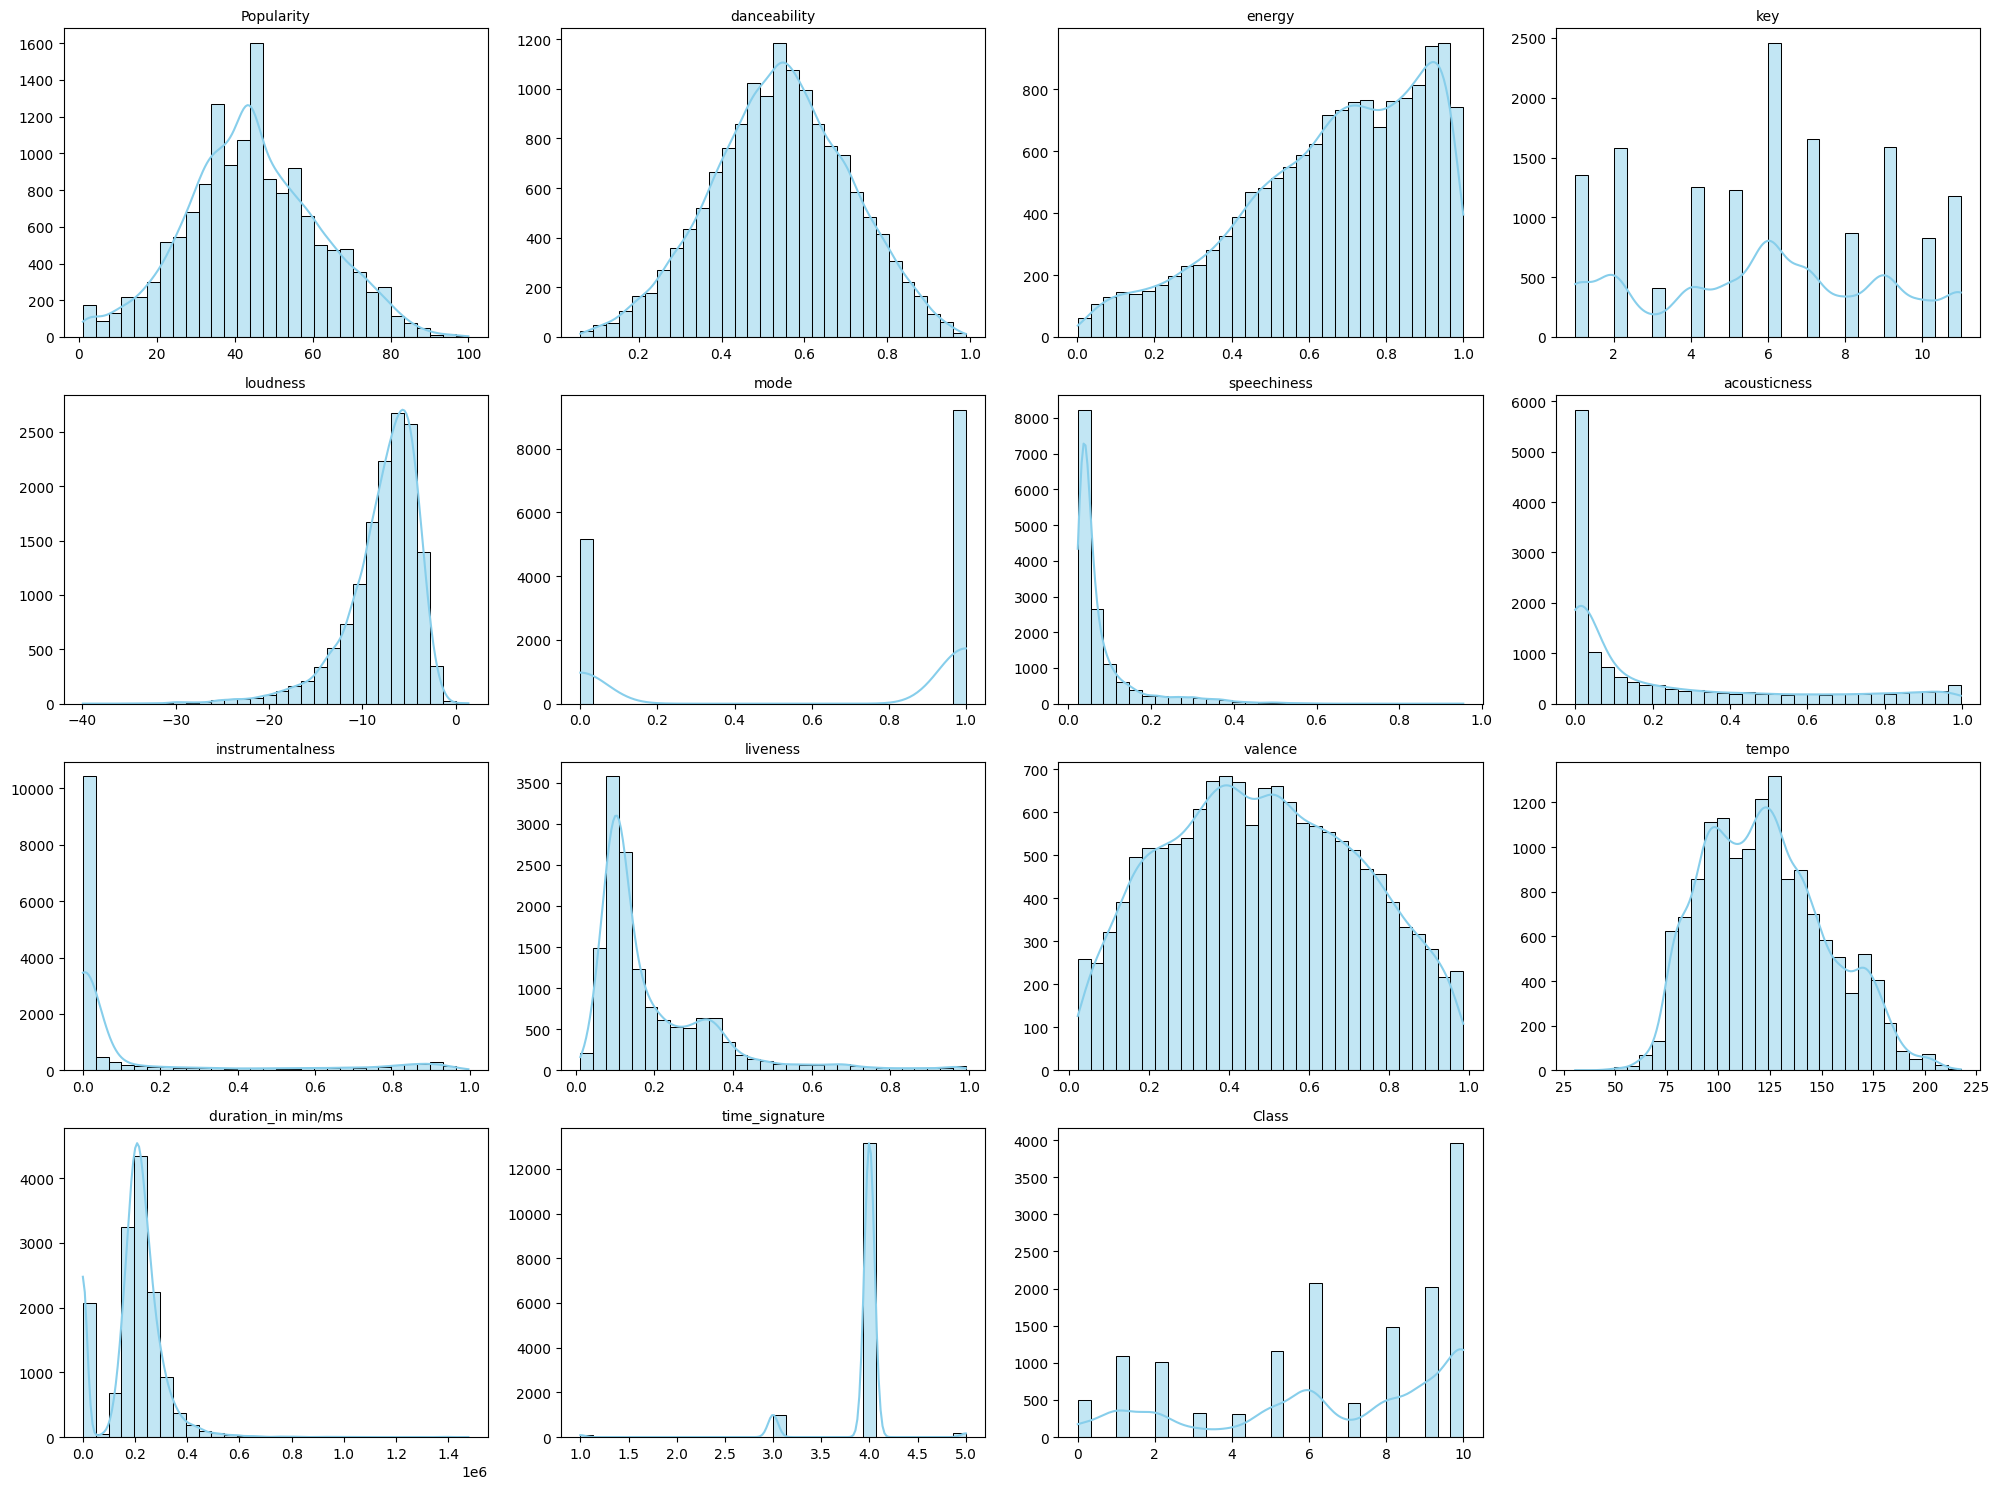

In [7]:
# Tạo lưới biểu đồ
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
axes = axes.flatten()

# Lặp qua các cột trong dataframe
for i, col in enumerate(train_data.select_dtypes(include=['int64', 'float64']).columns):
    sns.histplot(train_data[col], bins=30, kde=True, color='skyblue', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Xóa các subplot không dùng đến (dư thừa)
for j in range(len(train_data.select_dtypes(include=['int64', 'float64']).columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_hist1.png")
plt.show()

**Nhận xét:**
- Cột Popularity có phân bố gần chuẩn, chỉ có một số phần tử ở khoảng 30 - 50 phân bố tương đối nhiều hơn mức bình thường.
- Cột Danceability có phân bố rất gần với dạng chuẩn, có thể không cần biến đổi chuẩn hóa dữ liệu.
- Cột Energy, Loudness có phân bố với xu hướng lệch trái.
- Cột Speechiness, Acousticness, Instrumentalness có phân bố với xu hướng lệch phải mạnh.
- Cột Liveness có phân bố với xu hướng lệch phải.
- Cột Valence có phân bố đồng đều nhưng không phải phân bố chuẩn (phân bố hình bán nguyệt).
- Cột Tempo có phân bố lệch với dạng phân phối chuẩn.
- Cột Duration_in min/ms có phân bố lệch phải và có nhiều giá trị gần 0.
- Cột Key có phân bố rời rạc, với giá trị 6 có phân bố lớn nhất.
- Cột Mode có phân bố rời rạc, với giá trị 1 có phân bố lớn nhất.
- Cột Time_signature có phân bố rời rạc, với giá trị 4 phân bố nhiều nhất.

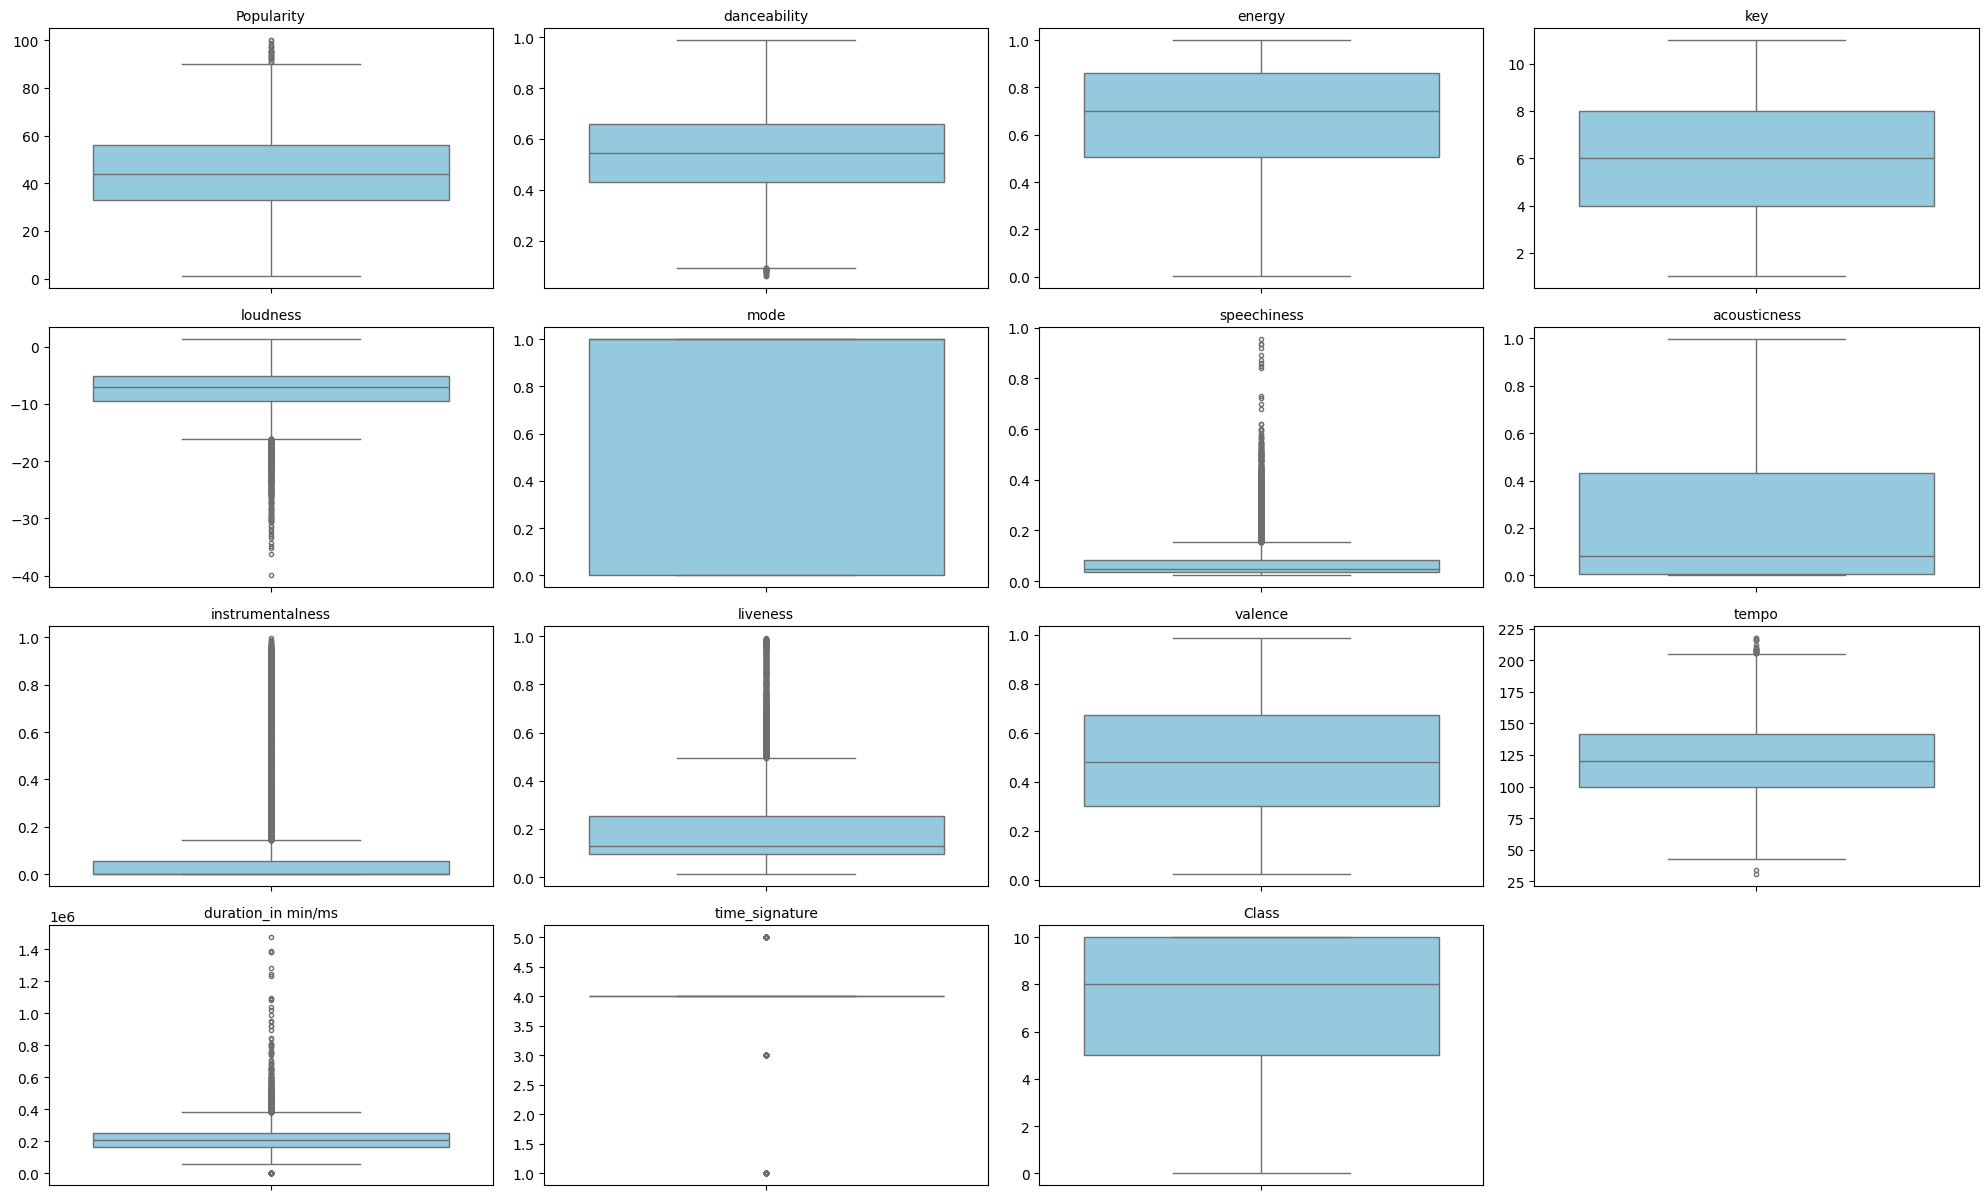

In [8]:
# Tạo lưới biểu đồ
fig, axes = plt.subplots(10, 4, figsize=(20, 30))
axes = axes.flatten()

# Lặp qua các cột trong dataframe
for i, col in enumerate(train_data.select_dtypes(include=['int64', 'float64']).columns):
    sns.boxplot(train_data[col], color="skyblue", fliersize=3, linewidth=1, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Xóa các subplot không dùng đến (dư thừa)
for j in range(len(train_data.select_dtypes(include=['int64', 'float64']).columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Nhận xét:**
- Cột Popularity, Danceability có phân bố gần chuẩn với ít giá trị ngoại lai.
- Cột Energy có phân bố lệch trái nhưng không có giá trị ngoại lai.
- Cột Spechiness, Instrumentalness, Liveness, Duration_in min/ms có phân bố lệch phải với nhiều giá trị ngoại lai.

#### **2) Biến Artist Name**

In [9]:
print(f"Số tên nghệ sĩ trên số dòng tập dữ liệu train: {len(train_data["Artist Name"].unique())} / {len(train_data["Artist Name"])}")
print(f"Số tên nghệ sĩ trên số dòng tập dữ liệu test: {len(test_data["Artist Name"].unique())} / {len(test_data["Artist Name"])}")

Số tên nghệ sĩ trên số dòng tập dữ liệu train: 7913 / 14396
Số tên nghệ sĩ trên số dòng tập dữ liệu test: 2784 / 3600


**Nhận xét:**
- Có một số nghệ sĩ trong tập train và test sáng tác nhiều hơn 1 bản nhạc.

In [10]:
train_data["Artist Name"].value_counts(ascending=False).to_frame("Count").head(10)

,Count
Artist Name,
Backstreet Boys,58
Westlife,53
Britney Spears,47
Omer Adam,39
Eyal Golan,38
Shlomo Artzi,32
Dudu Aharon,29
Hadag Nahash,29
Arik Einstein,29


**Nhận xét:**
- Nghệ sĩ Backstreet Boys sáng tác nhiều bản nhạc nhất với 58 bài.

In [11]:
print(f"Số nghệ sĩ có nhiều hơn 1 bản nhạc: {(train_data["Artist Name"].value_counts() > 1).sum()}")

Số nghệ sĩ có nhiều hơn 1 bản nhạc: 2624


**Nhận xét:**
- Có 2624 nghệ sĩ có nhiều hơn 1 bản nhạc trong tập train.

In [12]:
nltk.download('stopwords') # Tải danh sách các từ stopwords (ví dụ the, of, a,...) 

stop_words = set(stopwords.words('english')) # Lấy danh sách stopwords tiếng Anh

# Dọn dẹp chuỗi
def clean_text(text):
    if pd.isna(text):
        return ""
    # Chuyển chữ thường
    text = text.lower()
    # Chỉ giữ các chữ cái Latin và khoảng trắng
    text = re.sub(r'[^\p{L}\s]', '', text)
    # Loại khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    return text

all_words = train_data["Artist Name"].apply(clean_text).str.split().sum() # Lấy ra tổng số từ trong cột Artist Name.
all_words_filtered = [w for w in all_words if w not in stop_words] # Lọc bỏ những từ stopwords.

word_counts = Counter(all_words_filtered)

# Lấy các từ phổ biến nhất
n_words = 20
top_n_words = word_counts.most_common(n_words)

print(f"Top {n_words} từ phổ biến nhất:")
for word, count in top_n_words:
    print(f"{word}: {count} lần")


[nltk_data] Downloading package stopwords to C:\Users\QUOC
[nltk_data]     VIET\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 20 từ phổ biến nhất:
john: 108 lần
boys: 104 lần
black: 101 lần
band: 99 lần
king: 72 lần
james: 68 lần
kumar: 64 lần
ben: 60 lần
backstreet: 60 lần
spears: 57 lần
big: 55 lần
britney: 55 lần
dudu: 54 lần
westlife: 54 lần
trio: 54 lần
adam: 51 lần
young: 49 lần
red: 48 lần
mangeshkar: 47 lần
lata: 46 lần


**Nhận xét:**
Từ "john" xuất hiện nhiều nhất với 108 lần xuất hiện trên cột Artist Name.

In [13]:
 # Tải WordNet và omw cho xử lý từ đồng nghĩa
nltk.download('wordnet')
nltk.download('omw-1.4')

# Danh sách 20 từ phổ biến
top_words = [t[0] for t in top_n_words]

# Hàm tìm từ đồng nghĩa
def get_synonyms(word):
    syns = wordnet.synsets(word)
    lemmas = set()
    for syn in syns:
        for lemma in syn.lemmas():
            lemmas.add(lemma.name().lower().replace("_", " "))
    return lemmas

# Gom nhóm từ đồng nghĩa
synonym_groups = defaultdict(set)
for word in top_words:
    syns = get_synonyms(word)
    common_syns = syns.intersection(all_words_filtered) 
    synonym_groups[word].update(common_syns)
    synonym_groups[word].add(word)

# Chuyển set sang list
synonym_groups = {rep: sorted(list(words)) for rep, words in synonym_groups.items()}

# In nhóm từ đồng nghĩa
print("Nhóm từ đồng nghĩa:")
for rep, group in synonym_groups.items():
    print(f"- {rep}: {group}")

[nltk_data] Downloading package wordnet to C:\Users\QUOC
[nltk_data]     VIET\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\QUOC
[nltk_data]     VIET\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Nhóm từ đồng nghĩa:
- john: ['john', 'trick']
- boys: ['boy', 'boys', 'son']
- black: ['black', 'dark', 'inglorious']
- band: ['band', 'circle', 'ring', 'set']
- king: ['baron', 'king', 'power', 'queen', 'rex']
- james: ['jam', 'james', 'mob', 'pack', 'ram']
- kumar: ['kumar']
- ben: ['ben']
- backstreet: ['backstreet']
- spears: ['spears']
- big: ['adult', 'bad', 'big', 'great', 'handsome', 'heavy']
- britney: ['britney']
- dudu: ['dudu']
- westlife: ['westlife']
- trio: ['three', 'trey', 'trio']
- adam: ['adam', 'go', 'x', 'xtc']
- young: ['new', 'offspring', 'young', 'youth']
- red: ['cherry', 'crimson', 'red', 'ruby', 'scarlet', 'violent']
- mangeshkar: ['mangeshkar']
- lata: ['lata']


**Nhận xét:**
Các nhóm từ sau đây có thể được gom lại: 
- Group 1: cherry, crimson, red, ruby, scarlet
- Group 2: adult, bad, big, great, heavy
- Group 3: death, dead, destruction, dying, violent
- Group 4: offspring, young, youth
- Group 5: baron, king, power, queen, rex
- Group 6: black, dark, inglorious
- Group 7: brother, brothers, buddy
- Group 8: clean, snowy, white
- Group 9: blue, blues

Các từ này được chọn do chúng thường không được đặt theo tên thật của nghệ sĩ, có thể mang hàm ý nào đó.

#### **3) Biến Track Name** 

In [14]:
print(f"Số tên bản nhạc trên số dòng tập dữ liệu train: {len(train_data["Track Name"].unique())} / {len(train_data["Track Name"])}")
print(f"Số tên bản nhạc trên số dòng tập dữ liệu test: {len(test_data["Track Name"].unique())} / {len(test_data["Track Name"])}")

Số tên bản nhạc trên số dòng tập dữ liệu train: 12455 / 14396
Số tên bản nhạc trên số dòng tập dữ liệu test: 3472 / 3600


**Nhận xét:**
- Có một số bản nhạc trong tập train và test xuất hiện nhiều hơn 1 lần.

In [15]:
train_data["Track Name"].value_counts(ascending=False).to_frame("Count").head(10)

,Count
Track Name,
Fire,8
Ghost,7
Runaway,7
Control,6
Hurricane,6
Forever,6
Dreams,6
Blue,5
Run,5


**Nhận xét:**
- Bản nhạc "Fire" xuất hiện nhiều nhất (8 lần).

In [16]:
print(f"Số bản nhạc xuất hiện nhiều hơn 1 lần: {(train_data["Track Name"].value_counts() > 1).sum()}")

Số bản nhạc xuất hiện nhiều hơn 1 lần: 1526


**Nhận xét:**
- Có 1526 bản nhạc xuất hiện nhiều hơn 1 lần.

In [17]:
all_words = train_data["Track Name"].apply(clean_text).str.split().sum() # Lấy ra tổng số từ trong cột Artist Name.
all_words_filtered = [w for w in all_words if w not in stop_words] # Lọc bỏ những từ stopwords.

word_counts = Counter(all_words_filtered)

# Lấy các từ phổ biến nhất
n_words = 20
top_n_words = word_counts.most_common(n_words)

print(f"Top {n_words} từ phổ biến nhất:")
for word, count in top_n_words:
    print(f"{word}: {count} lần")


Top 20 từ phổ biến nhất:
feat: 520 lần
love: 356 lần
live: 213 lần
version: 207 lần
remastered: 184 lần
remaster: 180 lần
remix: 153 lần
acoustic: 150 lần
like: 128 lần
blues: 120 lần
time: 114 lần
dont: 103 lần
good: 103 lần
black: 102 lần
man: 99 lần
way: 92 lần
back: 91 lần
night: 90 lần
go: 90 lần
one: 89 lần


**Nhận xét:**
Từ "feat" xuất hiện nhiều nhất với 520 lần xuất hiện trên cột Track Name.

In [18]:
# Danh sách các từ phổ biến
top_words = [t[0] for t in top_n_words]

# Hàm tìm từ đồng nghĩa
def get_synonyms(word):
    syns = wordnet.synsets(word)
    lemmas = set()
    for syn in syns:
        for lemma in syn.lemmas():
            lemmas.add(lemma.name().lower().replace("_", " "))
    return lemmas

# Gom nhóm từ đồng nghĩa
synonym_groups = defaultdict(set)
for word in top_words:
    syns = get_synonyms(word)
    common_syns = syns.intersection(all_words_filtered) 
    synonym_groups[word].update(common_syns)
    synonym_groups[word].add(word)

# Chuyển set sang list
synonym_groups = {rep: sorted(list(words)) for rep, words in synonym_groups.items()}

# In nhóm từ đồng nghĩa
print("Nhóm từ đồng nghĩa:")
for rep, group in synonym_groups.items():
    print(f"- {rep}: {group}")

Nhóm từ đồng nghĩa:
- feat: ['feat']
- love: ['bang', 'bed', 'dear', 'dearest', 'enjoy', 'fuck', 'honey', 'jazz', 'know', 'love', 'screw']
- live: ['alive', 'dwell', 'exist', 'experience', 'go', 'hot', 'know', 'last', 'live', 'survive']
- version: ['edition', 'variant', 'variation', 'version']
- remastered: ['remastered']
- remaster: ['remaster']
- remix: ['remix']
- acoustic: ['acoustic']
- like: ['care', 'like', 'wish']
- blues: ['blue', 'blues']
- time: ['clip', 'clock', 'time']
- dont: ['dont']
- good: ['dear', 'full', 'good', 'honest', 'near', 'right', 'safe', 'serious', 'sound', 'well']
- black: ['black', 'contraband', 'dark', 'grim']
- man: ['human', 'humans', 'man', 'piece', 'world']
- way: ['direction', 'means', 'mode', 'path', 'room', 'style', 'way']
- back: ['back', 'backbone', 'cover', 'game', 'second', 'support']
- night: ['dark', 'night', 'nighttime']
- go: ['adam', 'become', 'belong', 'break', 'choke', 'crack', 'die', 'ecstasy', 'exit', 'fail', 'fling', 'get', 'go', 'las

**Nhận xét:**
Các nhóm từ sau đây có thể được gom lại: 
- Group 1: edition, version
- Group 2: remaster, remastered
- Group 3: acoustic
- Group 4: remix
- Group 5: feat

Những từ này được chọn do những từ này thường nói lên tính chất của bản nhạc, có thể ảnh hưởng đến kết quả dự đoán.


### 3.2. Phân tích hai biến

#### **1) Các biến số liên tục với biến mục tiêu (Class)**

##### a. Biến Popularity

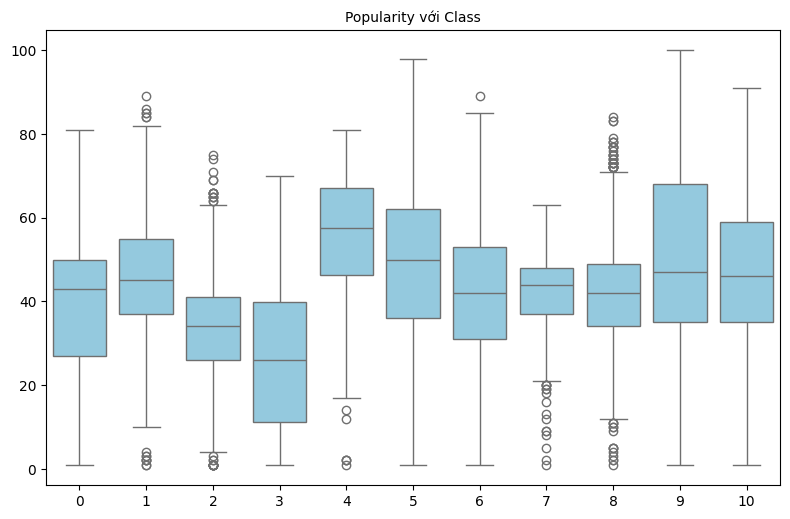

In [19]:
# Chọn các cột rời rạc.
num_cols = ["Popularity"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_popularity.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 4, 5 có phân bố trung bình cao nhất.
- Giá trị 2, 3 có phân bố trung bình thấp nhất.
- Giá trị 7, 8 có nhiều giá trị ngoại lai.

##### b. Biến Danceability

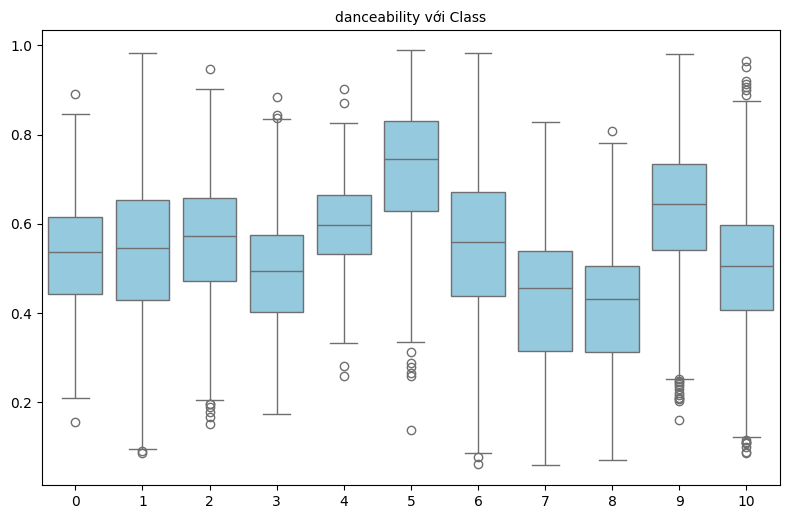

In [20]:

num_cols = ["danceability"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_danceability.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 5, 9 có phân bố trung bình cao nhất.
- Giá trị 7, 8 có phân bố trung bình thấp nhất.

##### c. Biến Energy

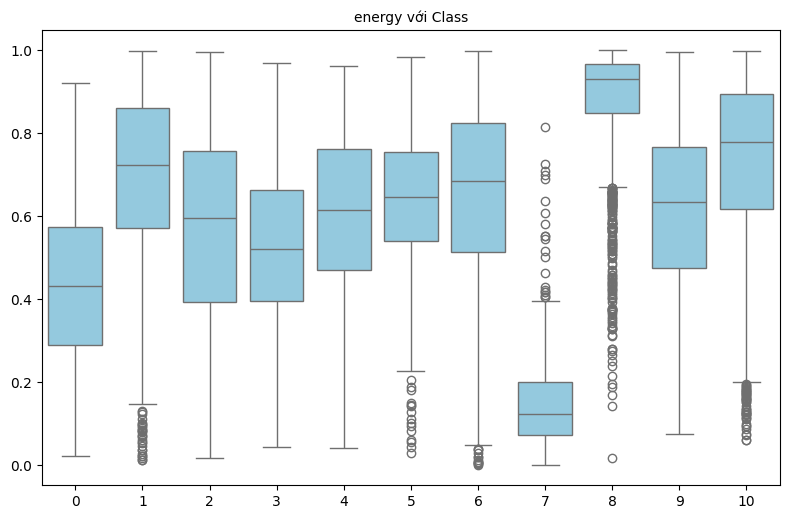

In [21]:

num_cols = ["energy"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_energy.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 8 có phân bố trung bình cao nhất với nhiều giá trị ngoại lai.
- Giá trị 7 có phân bố trung bình thấp nhất.
- Giá trị 1, 10 có nhiều giá trị ngoại lai.

##### d. Biến loudness

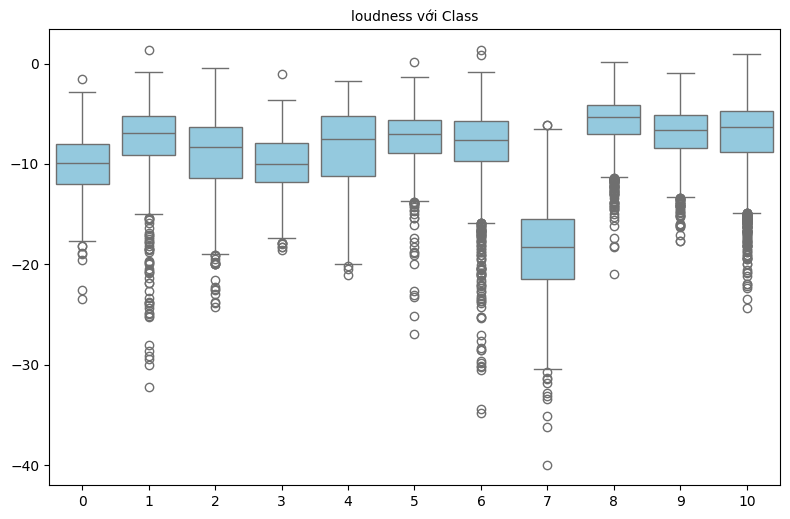

In [22]:

num_cols = ["loudness"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_loudness.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 7 có phân bố trung bình cao nhất.
- Hầu hết các giá trị có nhiều giá trị ngoại lai.

##### e. Biến speechiness

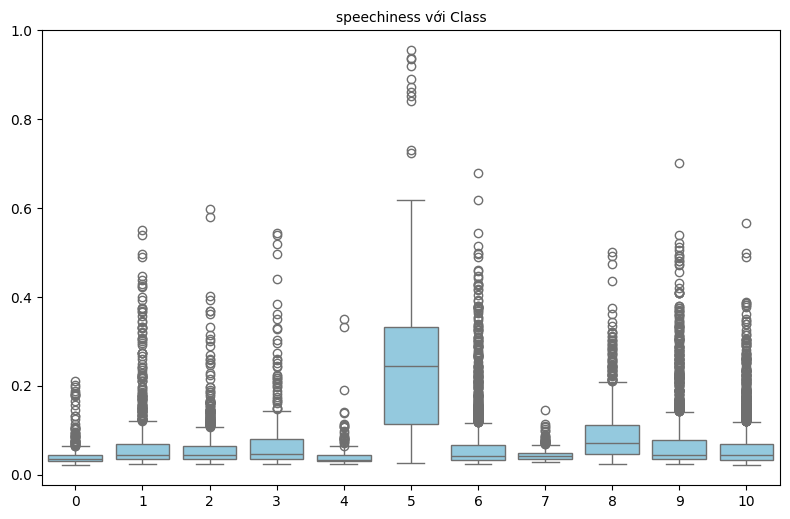

In [23]:

num_cols = ["speechiness"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_loudness.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 5 có phân bố trung bình cao nhất.
- Hầu hết các giá trị khác phân bố thấp hơn với nhiều giá trị ngoại lai.
- Giá trị 7 phân tán ít.

##### f. Biến acousticness

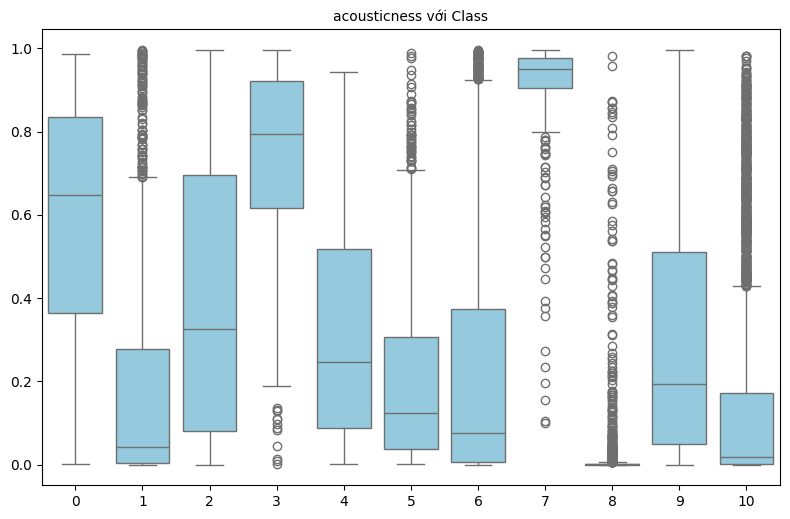

In [24]:

num_cols = ["acousticness"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_acousticness.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 7 có phân bố trung bình cao nhất.
- Giá trị 8 có phân bố trung bình thấp nhất với nhiều giá trị ngoại lai.
- Giá trị 1, 5, 6, 10 có nhiều giá trị ngoại lai.

##### g. Biến instrumentalness

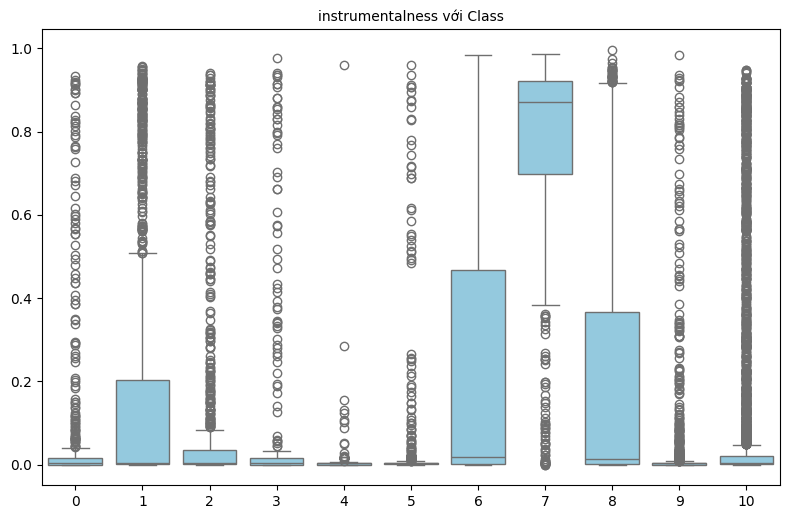

In [25]:

num_cols = ["instrumentalness"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_acousticness.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 7 có phân bố trung bình cao nhất.
- Hầu hết các giá trị khác phân bố thấp hơn với nhiều giá trị ngoại lệ.

##### h. Biến liveness

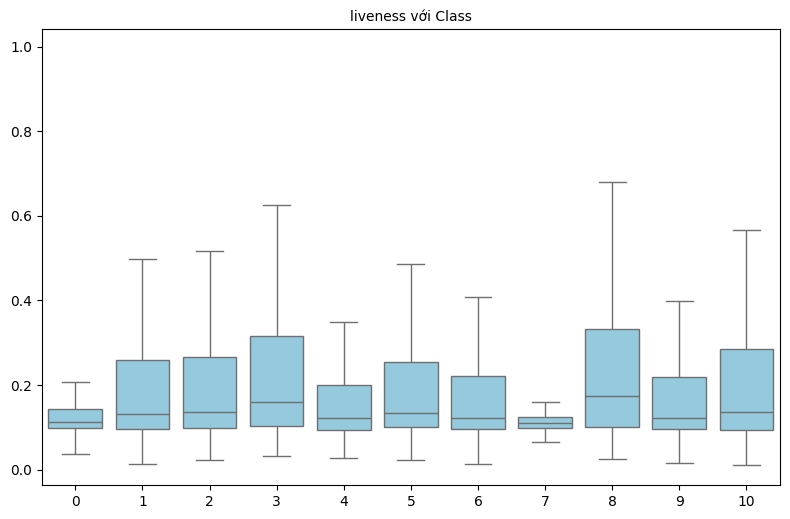

In [26]:
num_cols = ["liveness"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Vẽ boxplot
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue',
        fliersize=0  # ẩn outliers vì stripplot sẽ hiển thị điểm
    )
    
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_strip_liveness.png", dpi=150, bbox_inches='tight')
plt.show()


**Nhận xét:**
- Giá trị 3, 8 phân tán nhiều.
- Giá trị 0, 7 phân tán ít.

##### i. Biến valence

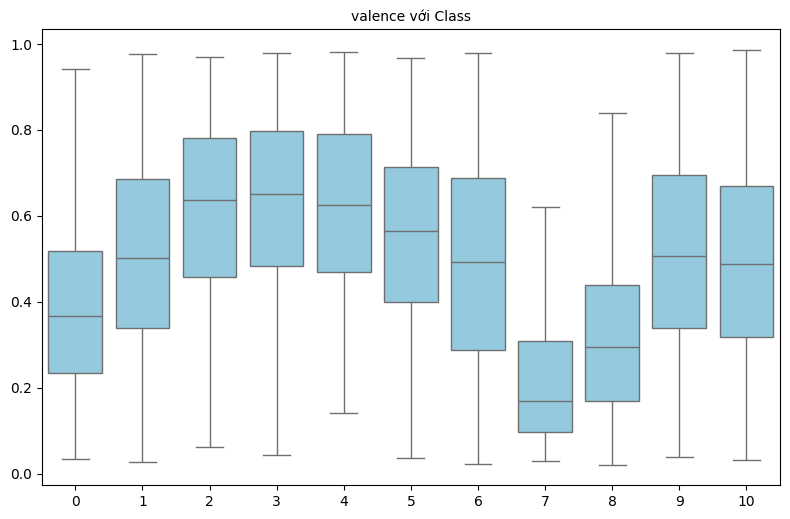

In [27]:
num_cols = ["valence"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Vẽ boxplot
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue',
        fliersize=0  # ẩn outliers vì stripplot sẽ hiển thị điểm
    )
    
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_strip_valence.png", dpi=150, bbox_inches='tight')
plt.show()


**Nhận xét:**
- Giá trị 7, 8 có phân bố trung bình thấp nhất.
- Giá trị 2, 3, 4 có phân bố trung bình cao nhất.

##### j. Biến tempo

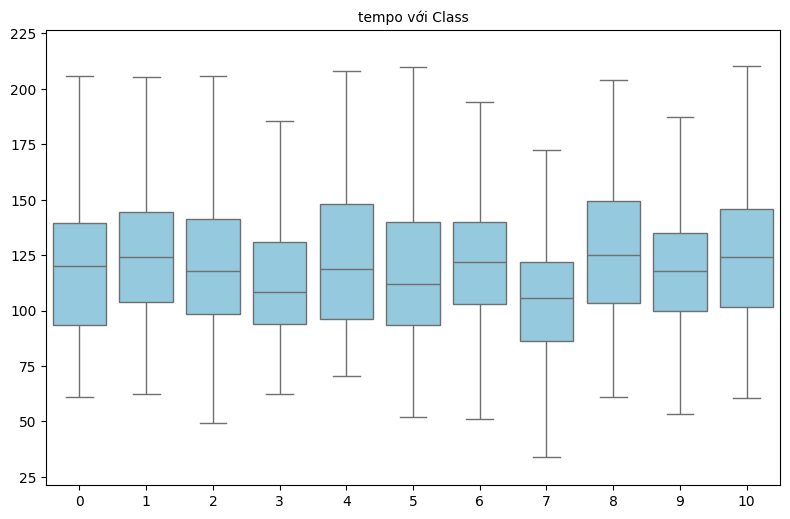

In [28]:
num_cols = ["tempo"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Vẽ boxplot
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue',
        fliersize=0  # ẩn outliers vì stripplot sẽ hiển thị điểm
    )
    
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_strip_tempo.png", dpi=150, bbox_inches='tight')
plt.show()


**Nhận xét:**
- Giá trị 3, 7 có phân bố trung bình thấp nhất.

##### k. Biến duration_in min/ms

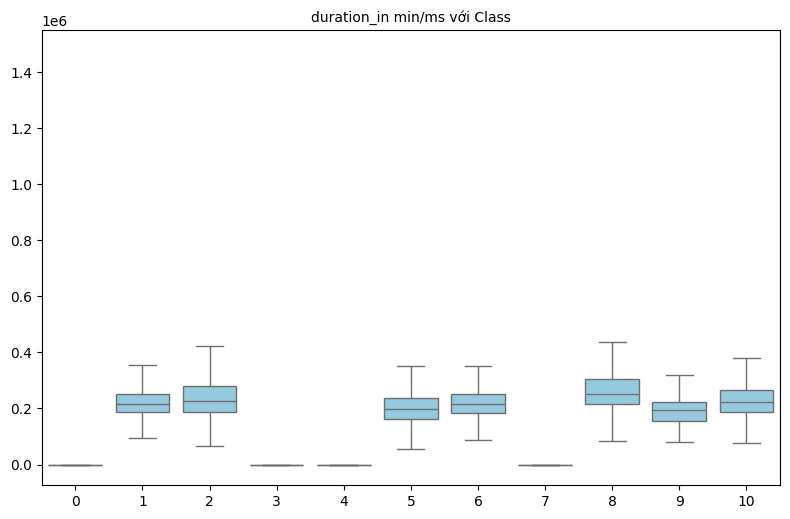

In [29]:
num_cols = ["duration_in min/ms"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Vẽ boxplot
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue',
        fliersize=0  # ẩn outliers vì stripplot sẽ hiển thị điểm
    )
    
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_strip_duration.png", dpi=150, bbox_inches='tight')
plt.show()


**Nhận xét:**
- Giá trị 0, 3, 4, 7 có phân bố trung bình thấp nhất và phân tán ít nhất.
- Các giá trị khác có phân bố trung bình cao hơn và phân tán nhiều hơn.

##### l. Hiển thị biểu đồ cho các biến

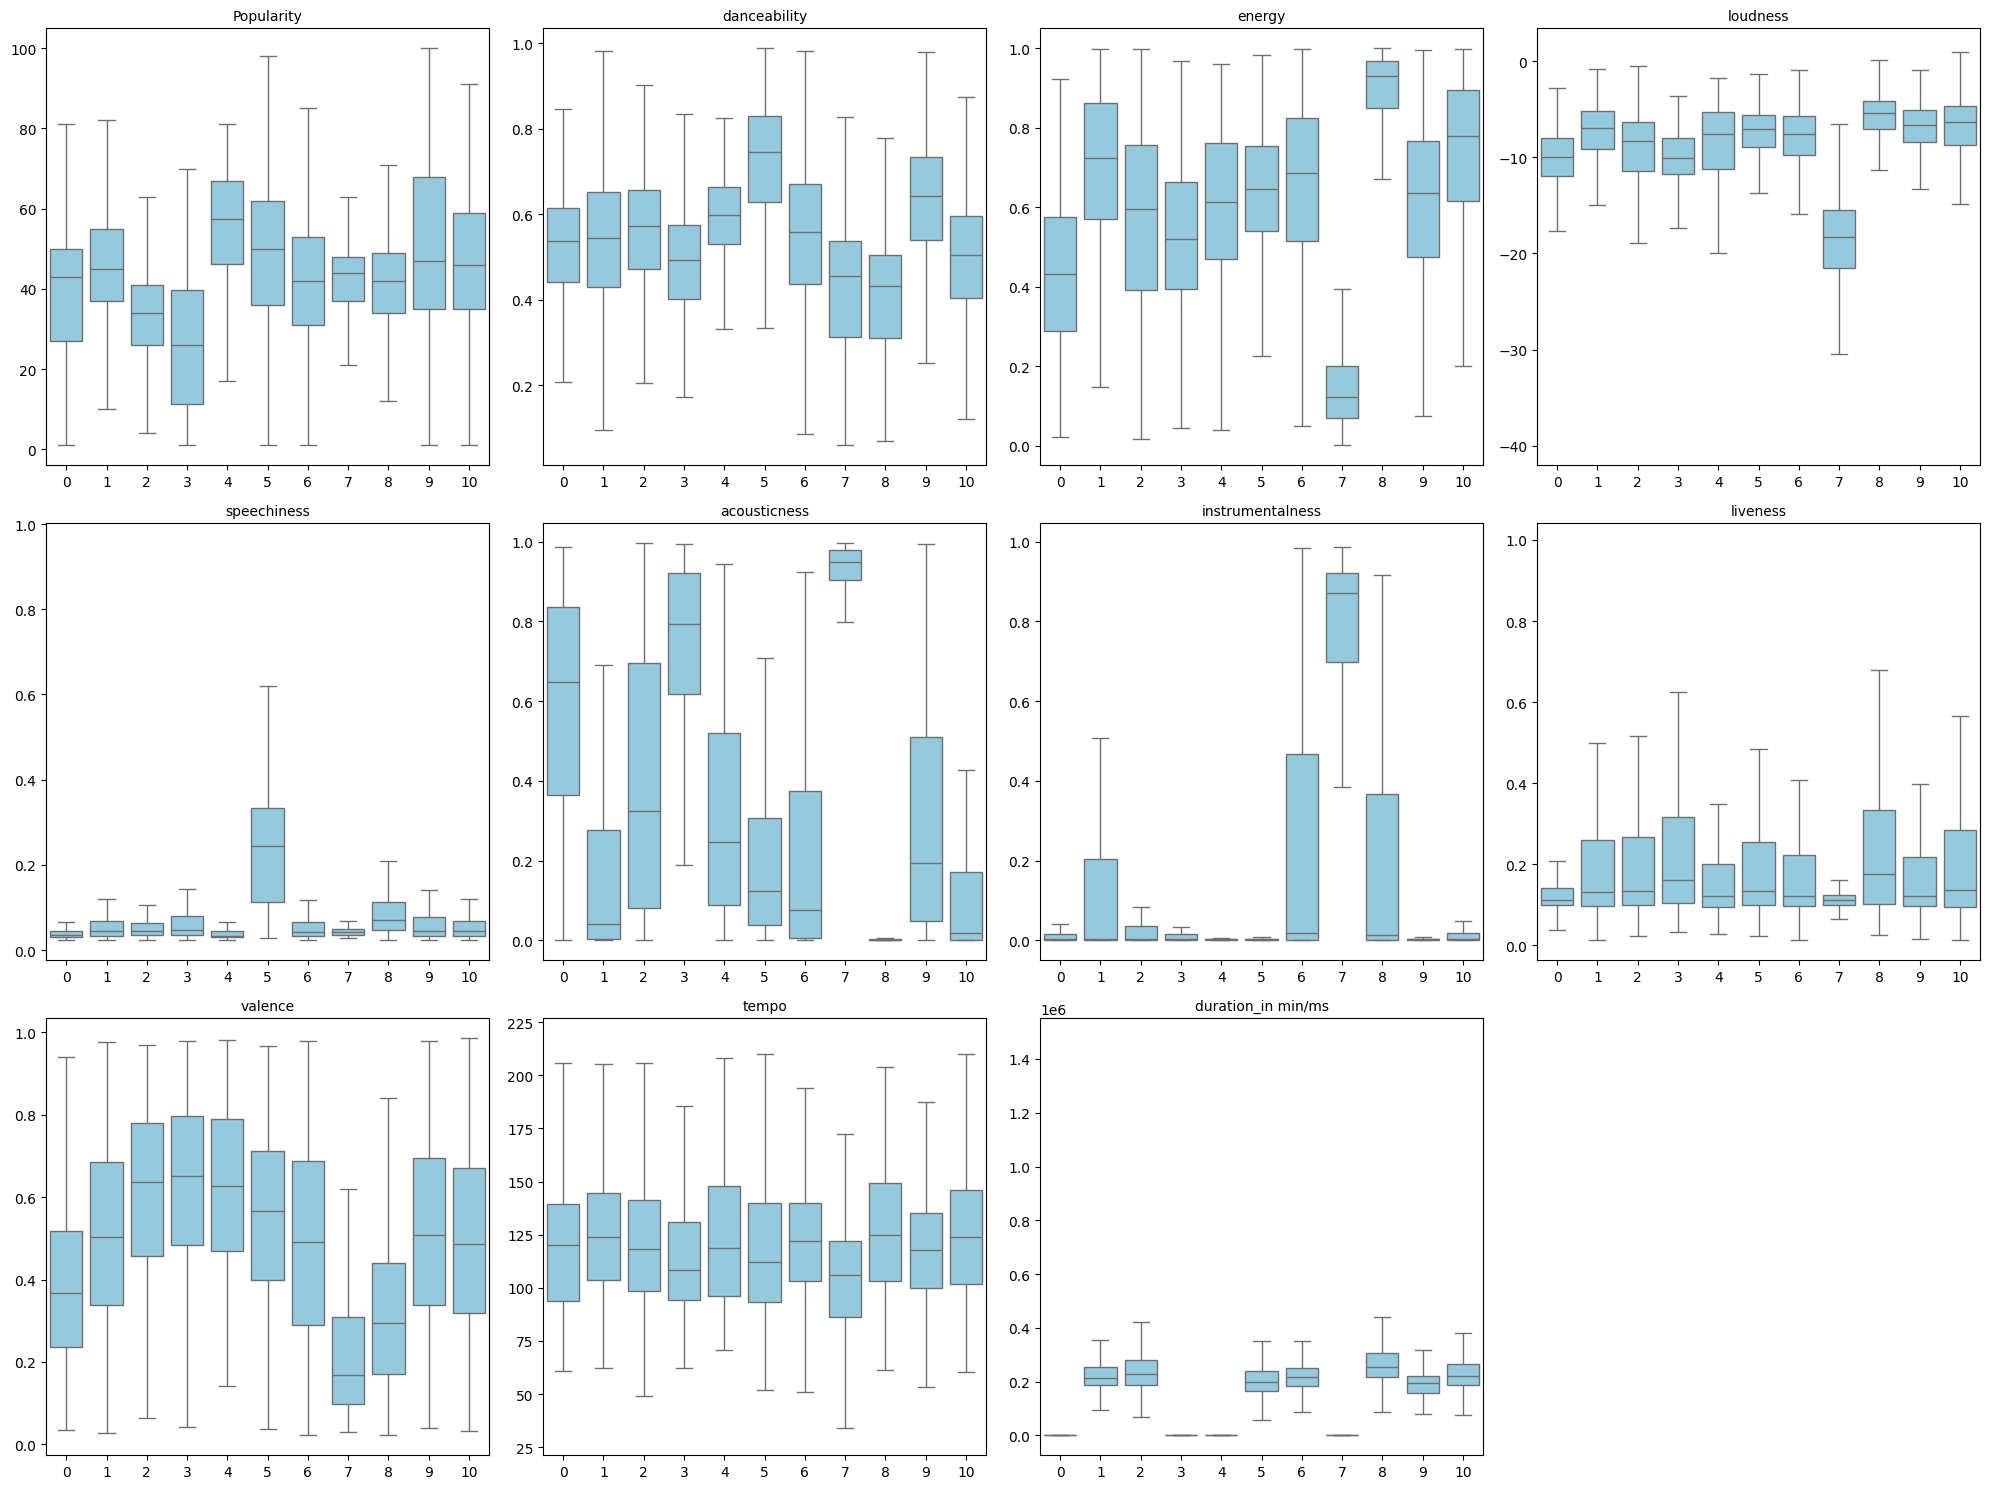

In [30]:
cols = ["Popularity", "danceability", "energy", "loudness", "speechiness", "acousticness",
        "instrumentalness", "liveness", "valence", "tempo", "duration_in min/ms"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

# Lặp qua các cột trong dataframe
for i, col in enumerate(cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue',
        fliersize=0  # ẩn outliers vì stripplot sẽ hiển thị điểm
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Xóa các subplot không dùng đến (dư thừa)
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_numbers.png")
plt.show()

#### **2) Các biến số rời rạc với biến mục tiêu (Class)**

##### a. Biến key

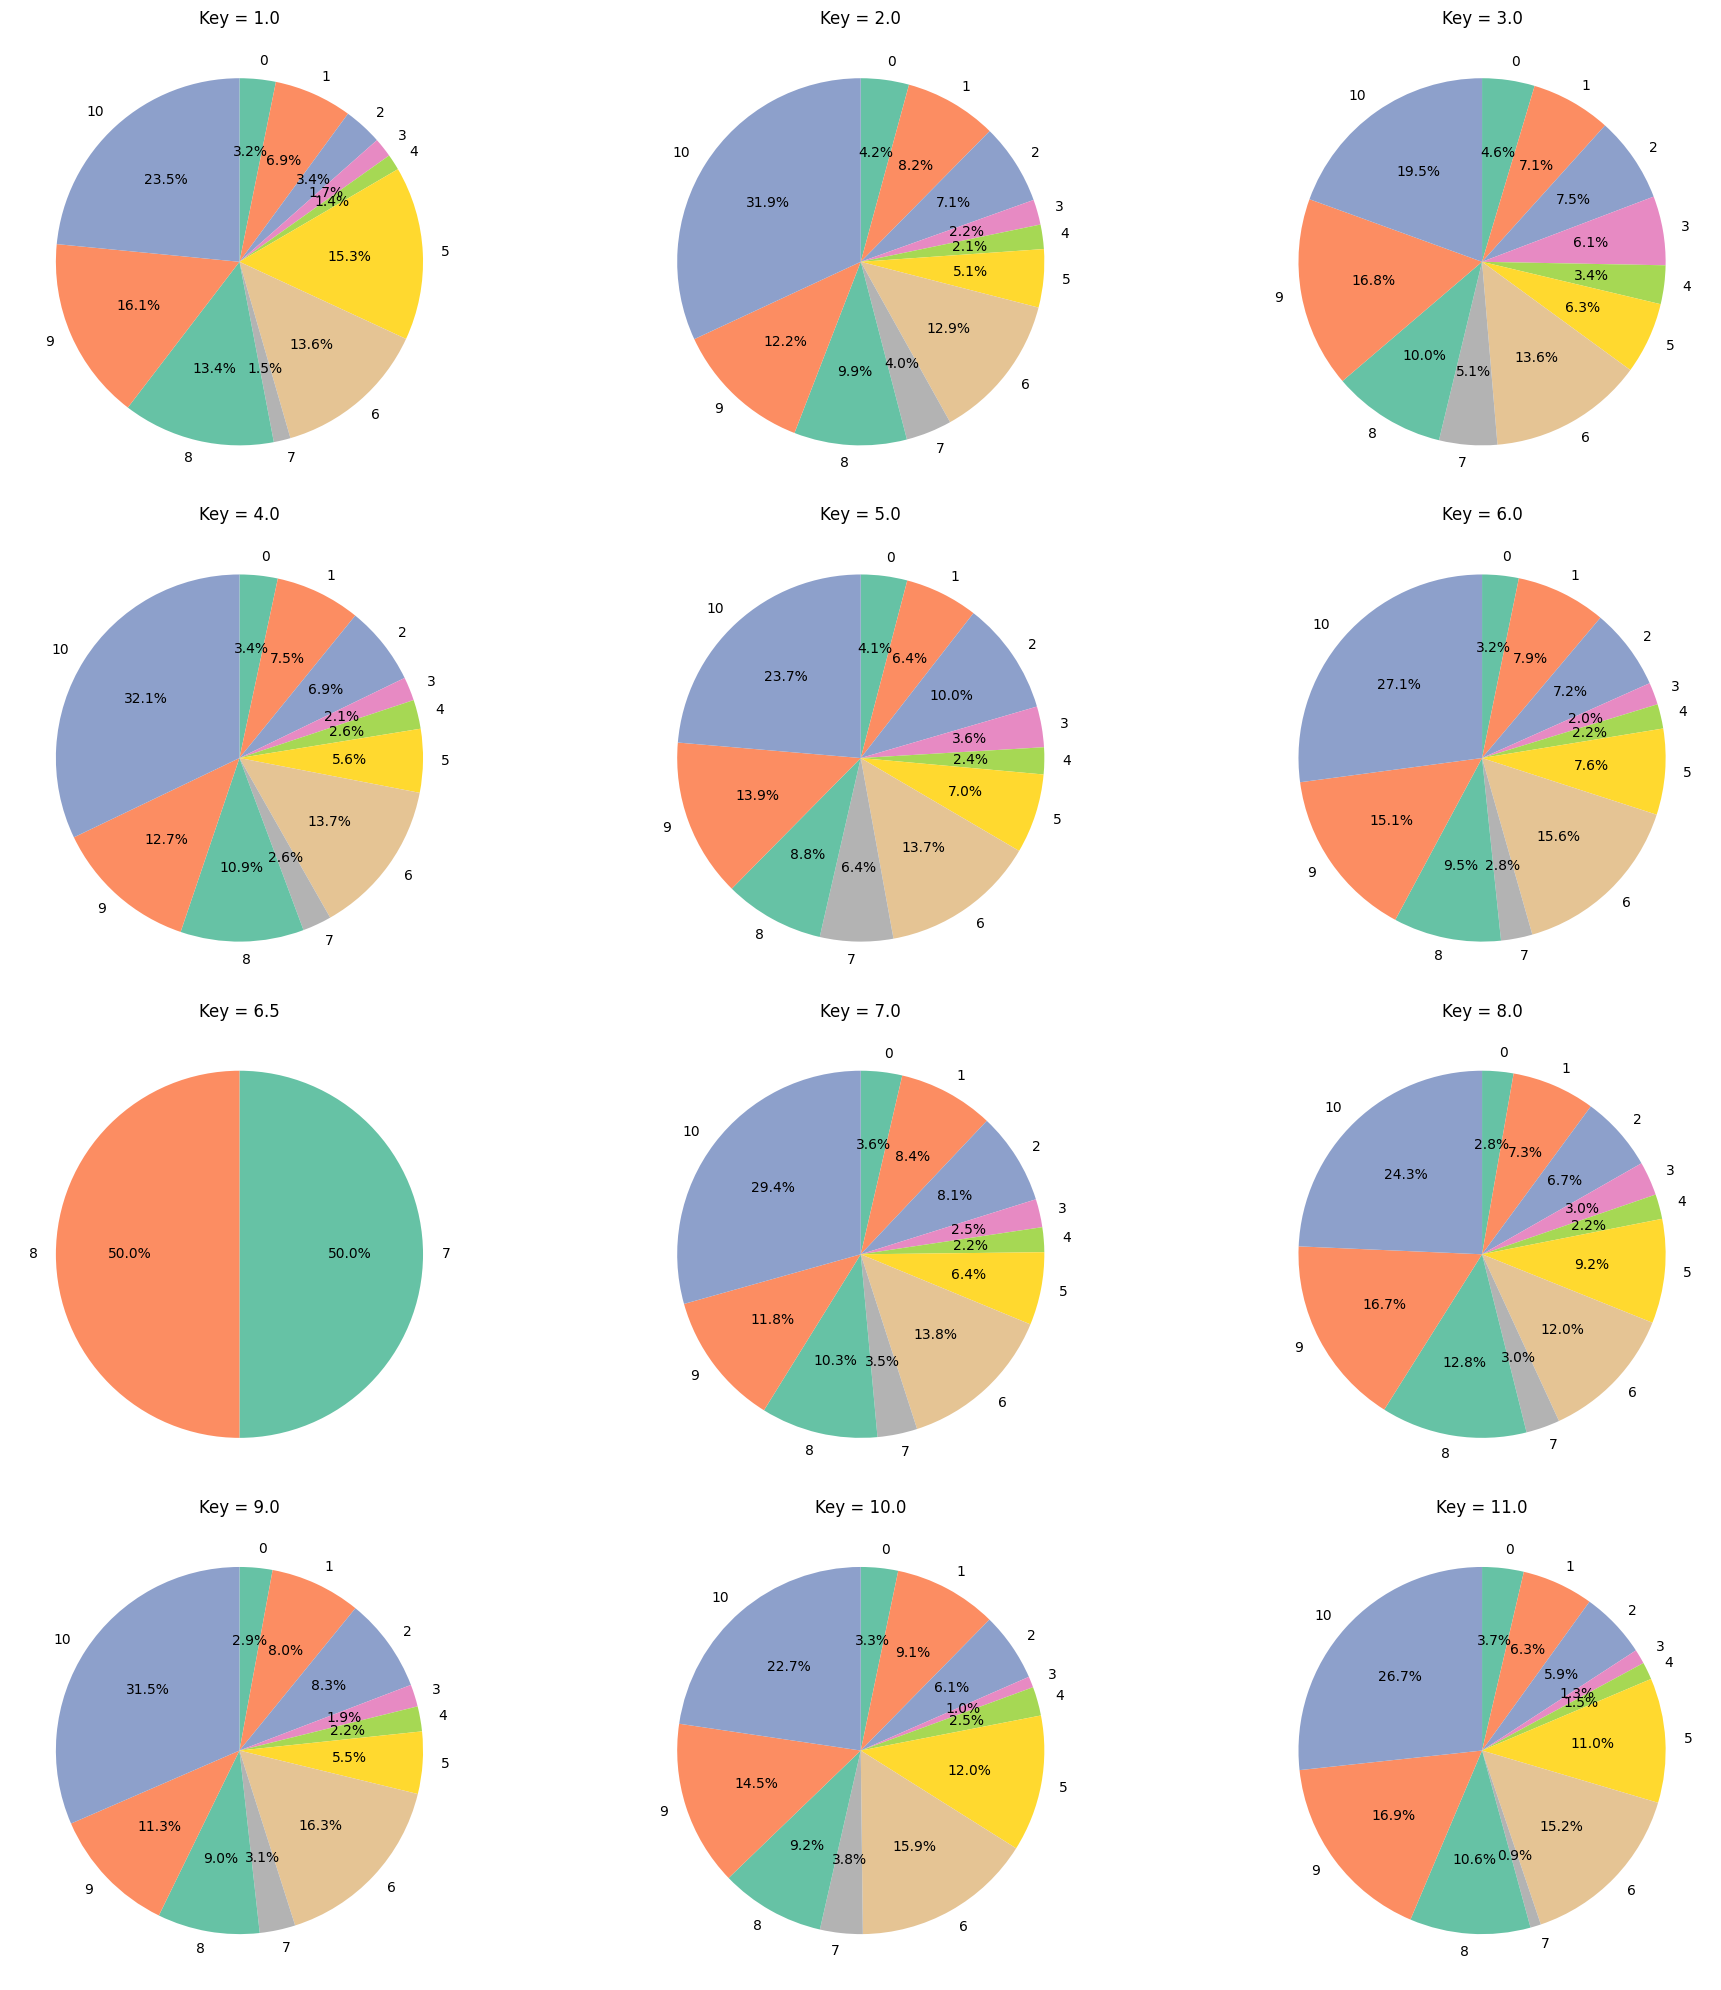

In [31]:
import matplotlib.pyplot as plt

# --- Tính số lượng mỗi Class trên từng key ---
count_df = train_data.groupby(['key', 'Class']).size().reset_index(name='count')

# --- Lấy danh sách key ---
keys = count_df['key'].unique()

# --- Vẽ biểu đồ tròn cho từng key ---
plt.figure(figsize=(20, 20))
n_keys = len(keys)
cols = 3  # số cột biểu đồ
rows = (n_keys + cols - 1) // cols  # tính số hàng cần thiết

for i, key in enumerate(keys, 1):
    plt.subplot(rows, cols, i)
    data = count_df[count_df['key'] == key]
    plt.pie(
        data['count'],
        labels=data['Class'],
        autopct='%1.1f%%',  # hiển thị tỷ lệ phần trăm
        colors=plt.cm.Set2.colors,
        startangle=90,
        counterclock=False
    )
    plt.title(f'Key = {key}')

plt.tight_layout()
plt.show()


**Nhận xét:**
- Giá trị class = 0 có tỷ lệ phân bố nhiều nhất trên key = 3 (4.6%) và ít nhất trên key = 8 (2.8%).
- Giá trị class = 1 có tỷ lệ phân bố nhiều nhất trên key = 10 (9.1%) và ít nhất trên key = 11 (6.3%).
- Giá trị class = 2 có tỷ lệ phân bố nhiều nhất trên key = 5 (10.0%) và ít nhất trên key = 1 (3.4%).
- Giá trị class = 3 có tỷ lệ phân bố nhiều nhất trên key = 5 (3.6%) và ít nhất trên key = 10 (1.0%).
- Giá trị class = 4 có tỷ lệ phân bố nhiều nhất trên key = 3 (3.4%) và ít nhất trên key = 1 (1.4%).
- Giá trị class = 5 có tỷ lệ phân bố nhiều nhất trên key = 1 (15.3%) và ít nhất trên key = 2 (5.1%).
- Giá trị class = 6 có tỷ lệ phân bố nhiều nhất trên key = 10 (15.9%) và ít nhất trên key = 8 (12.0%).
- Giá trị class = 7 có tỷ lệ phân bố nhiều nhất trên key = 6.5 (50%), nhiều thứ hai với key = 5 (6.4%) và ít nhất trên key = 11 (0.9%).
- Giá trị class = 8 có tỷ lệ phân bố nhiều nhất trên key = 6.5 (50%), nhiều thứ hai với key = 1 (13.4%) và ít nhất trên key = 5 (8.8%).
- Giá trị class = 9 có tỷ lệ phân bố nhiều nhất trên key = 11 (16.9%) và ít nhất trên key = 9 (11.3%).
- Giá trị class = 10 có tỷ lệ phân bố nhiều nhất trên key = 4 (32.1%) và ít nhất trên key = 3 (19.5%).
- Key = 6.5 chỉ phân bố trên 2 class 7, 8 với tần suất 50%.


##### b. Biến mode

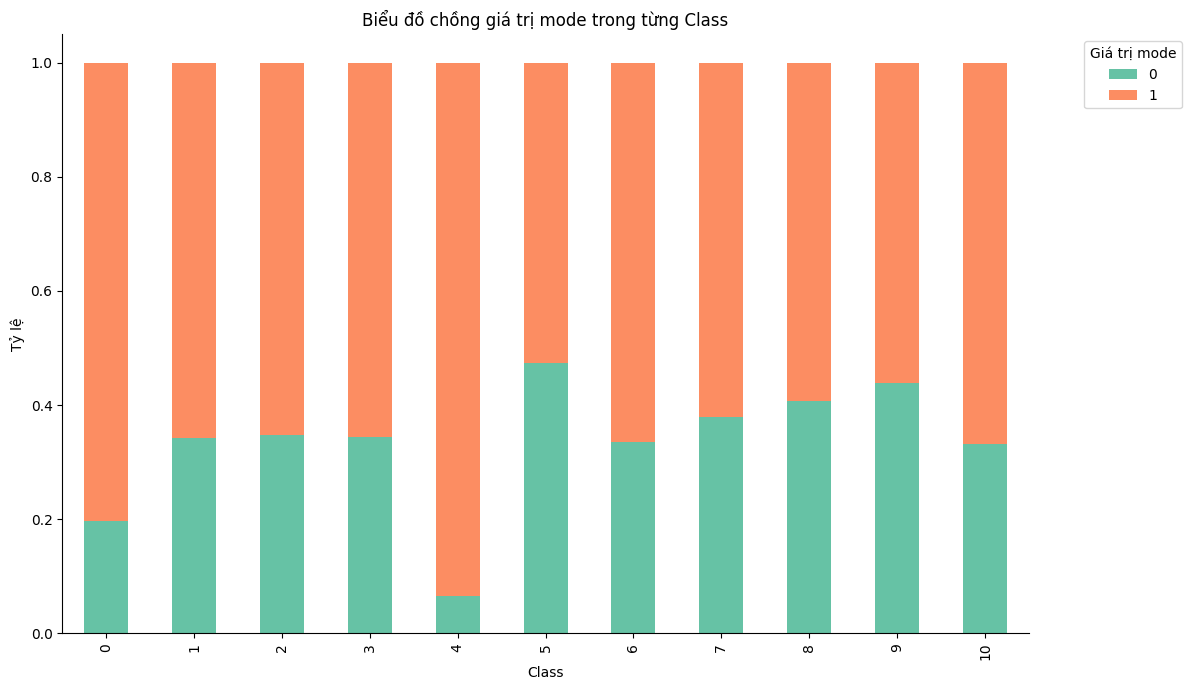

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Tính tần suất xuất hiện của từng mode trong từng Class
count_df = (
    train_data.groupby(['Class', 'mode'])
    .size()
    .reset_index(name='count')
)

# Pivot để tạo dạng bảng cột chồng
pivot_df = count_df.pivot(index='Class', columns='mode', values='count').fillna(0)

# (Tùy chọn) chuyển sang tỉ lệ %
pivot_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# Vẽ stacked bar chart
colors = sns.color_palette("Set2", len(pivot_df.columns))
pivot_df.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(12, 7)
)

plt.title("Biểu đồ chồng giá trị mode trong từng Class", fontsize=12)
plt.xlabel("Class")
plt.ylabel("Tỷ lệ")
plt.legend(
    title="Giá trị mode",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
sns.despine()
plt.tight_layout()
plt.show()


**Nhận xét:**
- Class = 4 có tỷ lệ phân phối mode = 0 thấp nhất và mode = 1 cao nhất.
- Class = 5 có tỷ lệ phân phối mode = 0 cao nhất và mode = 1 thấp nhất.

##### c. Biến time_signature

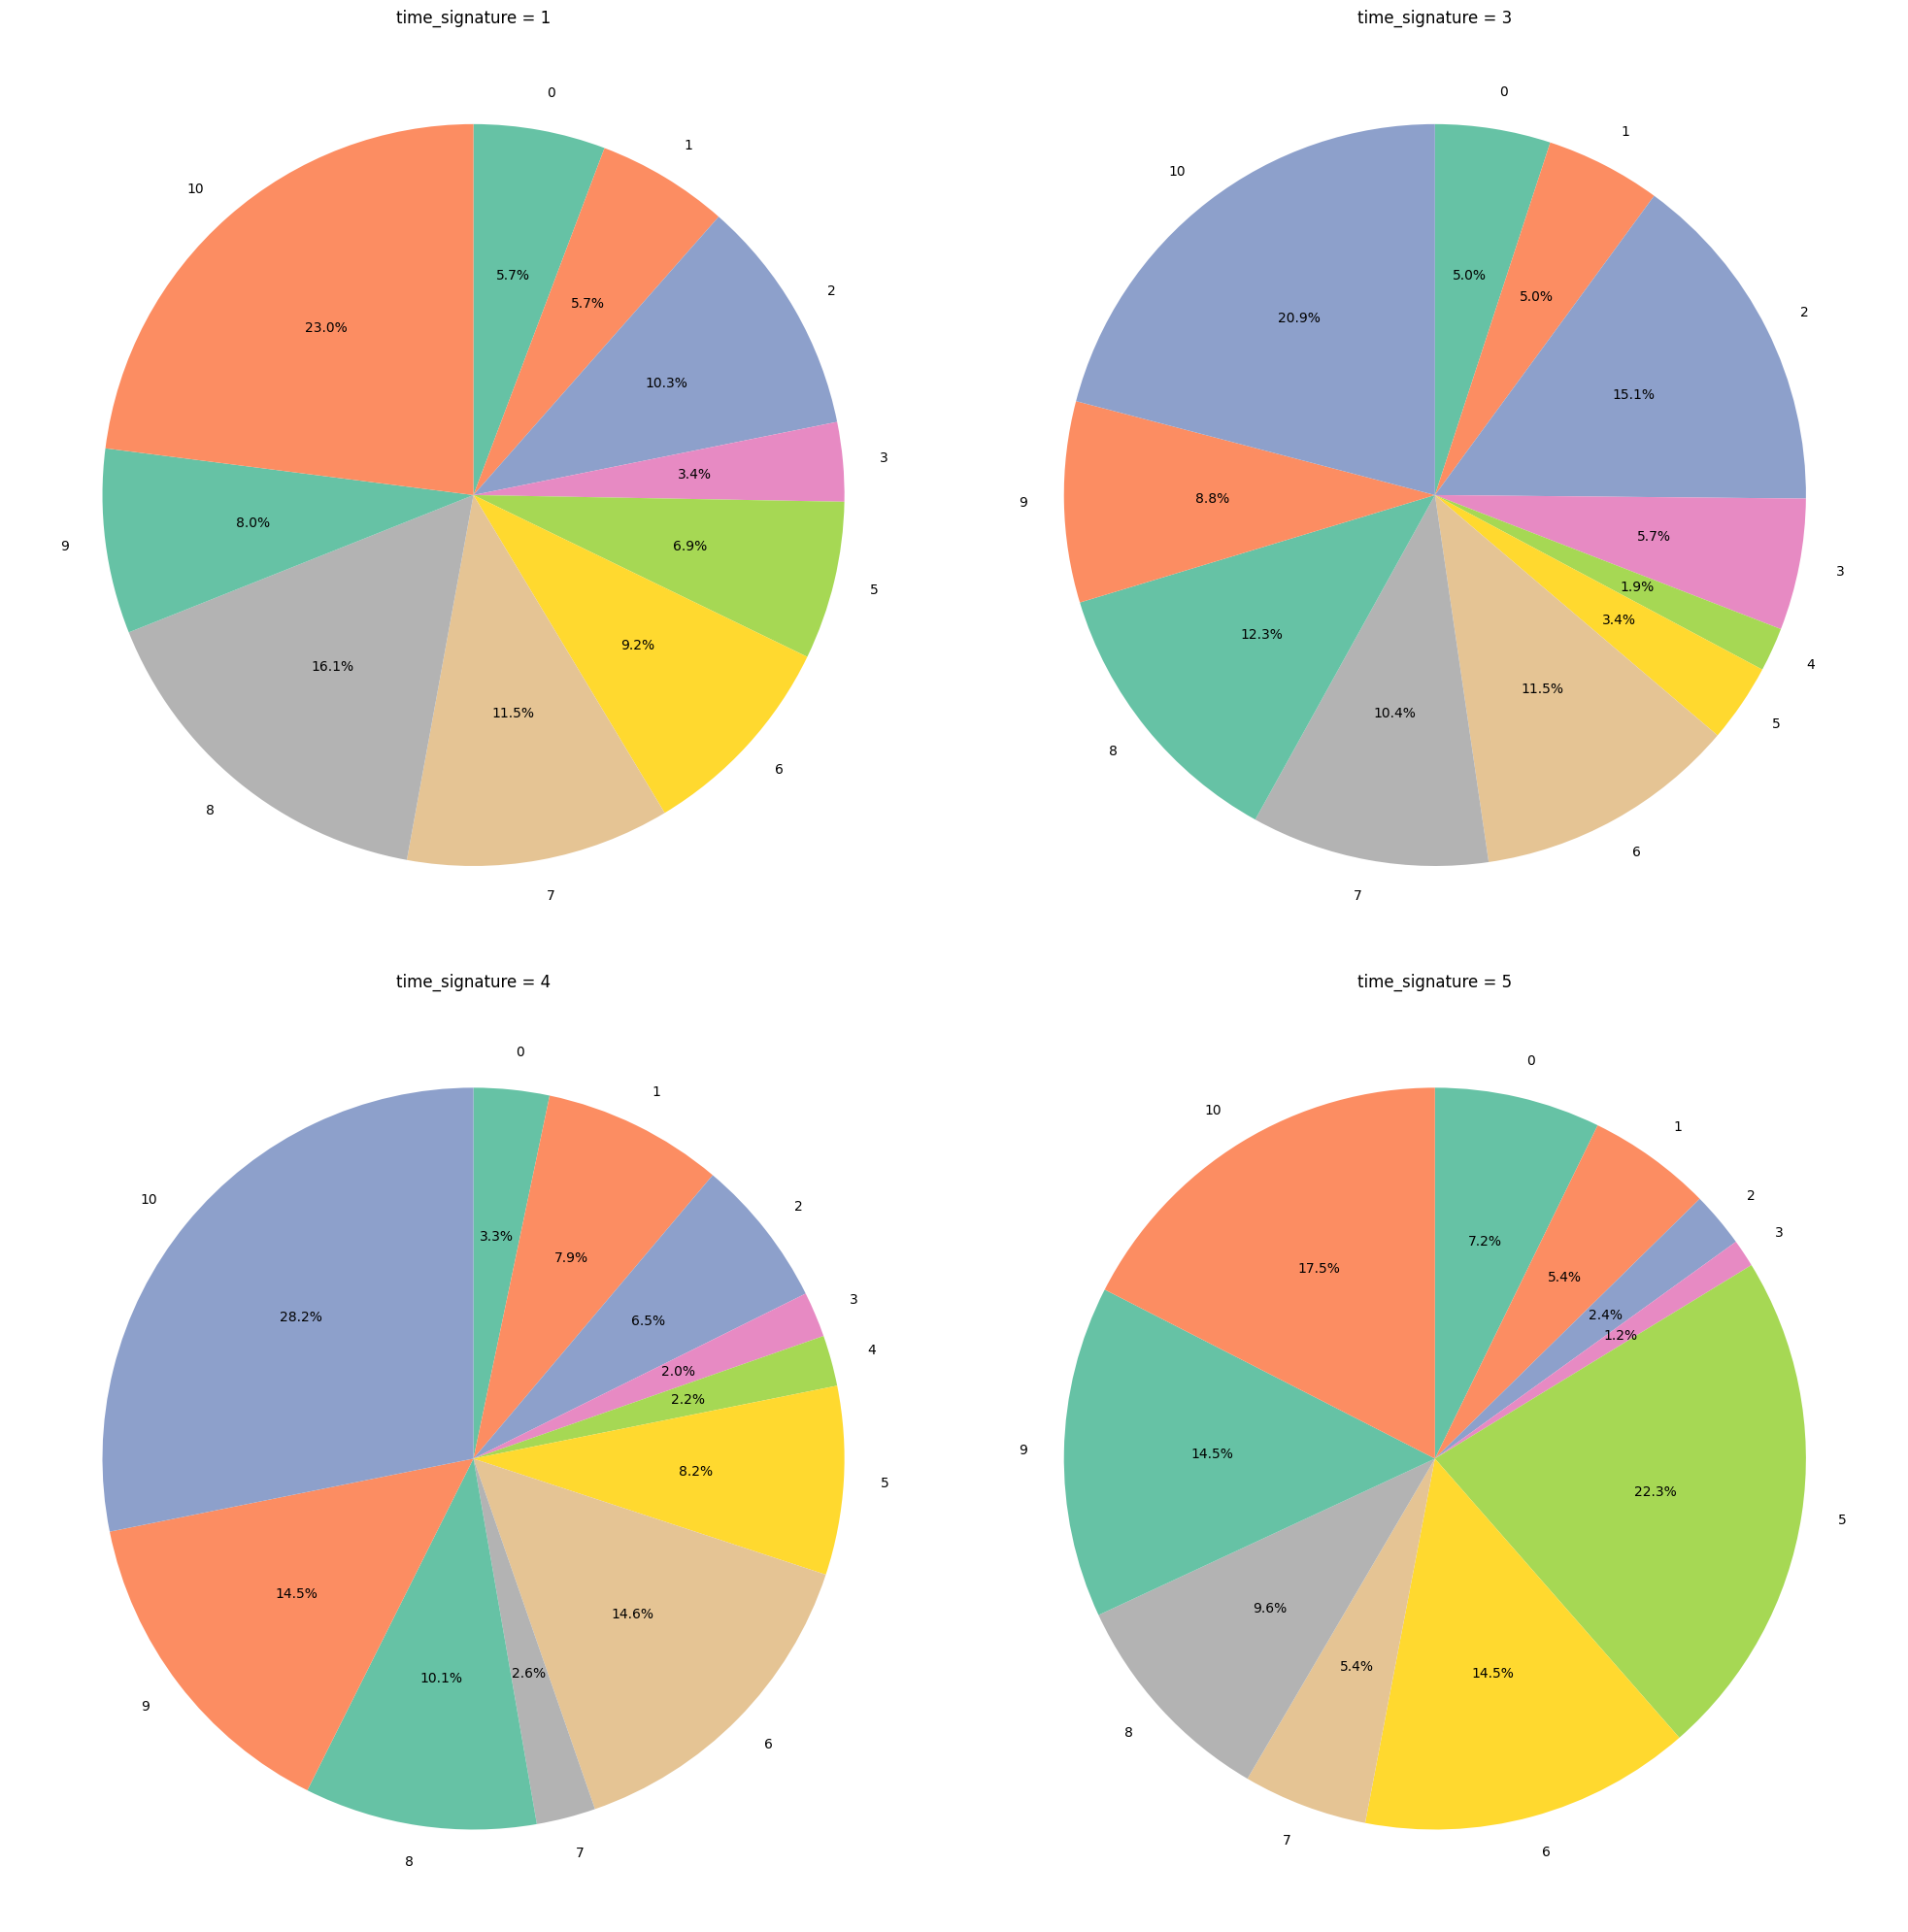

In [33]:
import matplotlib.pyplot as plt

# --- Tính số lượng mỗi Class trên từng time_signature ---
count_df = train_data.groupby(['time_signature', 'Class']).size().reset_index(name='count')

# --- Lấy danh sách time_signature ---
time_signatures = count_df['time_signature'].unique()

# --- Vẽ biểu đồ tròn cho từng time_signature ---
plt.figure(figsize=(20, 20))
n_time_signatures = len(time_signatures)
cols = 2  # số cột biểu đồ
rows = (n_time_signatures + cols - 1) // cols  # tính số hàng cần thiết

for i, time_signature in enumerate(time_signatures, 1):
    plt.subplot(rows, cols, i)
    data = count_df[count_df['time_signature'] == time_signature]
    plt.pie(
        data['count'],
        labels=data['Class'],
        autopct='%1.1f%%',  # hiển thị tỷ lệ phần trăm
        colors=plt.cm.Set2.colors,
        startangle=90,
        counterclock=False
    )
    plt.title(f'time_signature = {time_signature}')

plt.tight_layout()
plt.show()


**Nhận xét:**
- Giá trị class = 0 có tỷ lệ phân bố nhiều nhất trên time_signature = 5 (7.2%) và ít nhất trên time_signature = 4 (3.3%).
- Giá trị class = 1 có tỷ lệ phân bố nhiều nhất trên time_signature = 4 (7.9%) và ít nhất trên time_signature = 3 (5.0%).
- Giá trị class = 2 có tỷ lệ phân bố nhiều nhất trên time_signature = 3 (15.1%) và ít nhất trên time_signature = 5 (2.4%).
- Giá trị class = 3 có tỷ lệ phân bố nhiều nhất trên time_signature = 3 (5.7%) và ít nhất trên time_signature = 5 (1.2%).
- Giá trị class = 4 có tỷ lệ phân bố nhiều nhất trên time_signature = 4 (2.2%) và ít nhất trên time_signature = 3 (1.9%). 
- Giá trị class = 5 có tỷ lệ phân bố nhiều nhất trên time_signature = 5 (22.5%) và ít nhất trên time_signature = 3 (3.4%). 
- Giá trị class = 6 có tỷ lệ phân bố nhiều nhất trên time_signature = 4 (14.6%) và ít nhất trên time_signature = 1 (9.2%).
- Giá trị class = 7 có tỷ lệ phân bố nhiều nhất trên time_signature = 1 (11.5%) và ít nhất trên time_signature = 4 (2.6%).
- Giá trị class = 8 có tỷ lệ phân bố nhiều nhất trên time_signature = 1 (16.1%) và ít nhất trên time_signature = 5 (9.6%).
- Giá trị class = 9 có tỷ lệ phân bố nhiều nhất trên time_signature = 4, 5 (14.5%) và ít nhất trên time_signature = 1 (8.0%).
- Giá trị class = 10 có tỷ lệ phân bố nhiều nhất trên time_signature = 4 (28.2%) và ít nhất trên time_signature = 5 (17.5%).
- Giá trị class = 4 không phân bố trên time_signature = 1, 5.

#### **3) Biến Artist Name với biến mục tiêu (Class)**

In [34]:
categories = [
    "cherry crimson red ruby scarlet".split(),
    "adult bad big great heavy".split(),
    "death dead destruction dying violent".split(),
    "offspring young youth".split(),
    "baron king power queen rex".split(),
    "black dark inglorious".split(),
    "brother brothers buddy".split(),
    "clean snowy white".split(),
    "blue blues".split()
]
print(categories)

[['cherry', 'crimson', 'red', 'ruby', 'scarlet'], ['adult', 'bad', 'big', 'great', 'heavy'], ['death', 'dead', 'destruction', 'dying', 'violent'], ['offspring', 'young', 'youth'], ['baron', 'king', 'power', 'queen', 'rex'], ['black', 'dark', 'inglorious'], ['brother', 'brothers', 'buddy'], ['clean', 'snowy', 'white'], ['blue', 'blues']]


In [35]:
word_to_category = {}
for i, group in enumerate(categories):
    for w in group:
        word_to_category[w] = i

def get_categories_for_row(text):
    words = clean_text(text).lower().split()
    groups = set()
    for w in words:
        if w in word_to_category:
            groups.add(word_to_category[w] + 1)
    return sorted(groups)

# Tạo cột phân loại
train_data["CategoryGroups"] = train_data["Artist Name"].apply(get_categories_for_row)
train_data["CategoryGroups"].head()

0     []
1    [6]
2     []
3    [9]
4     []
Name: CategoryGroups, dtype: object

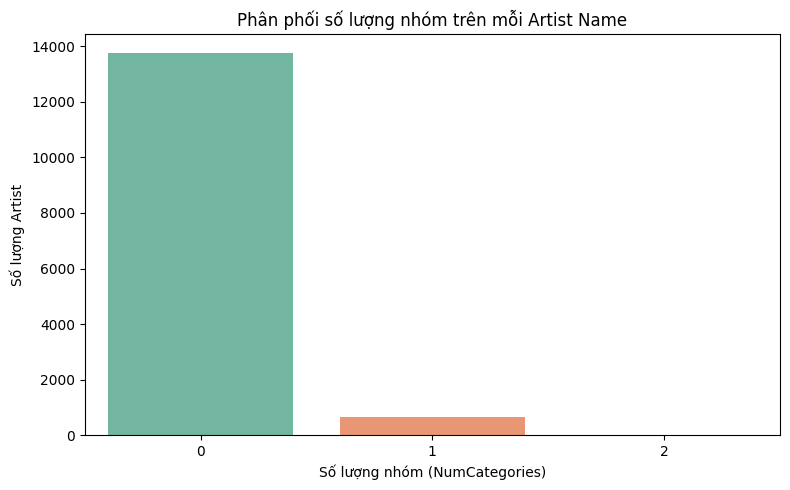

In [36]:
# tạo số lượng nhóm
train_data["NumCategories"] = train_data["CategoryGroups"].apply(len)

plt.figure(figsize=(8,5))
sns.countplot(data=train_data, x="NumCategories", palette="Set2")
plt.title("Phân phối số lượng nhóm trên mỗi Artist Name")
plt.xlabel("Số lượng nhóm (NumCategories)")
plt.ylabel("Số lượng Artist")

plt.tight_layout()
plt.show()

**Nhận xét:**
- Hầu hết các giá trị trong cột Artist Name không được mã hóa sang các nhóm phân loại. 

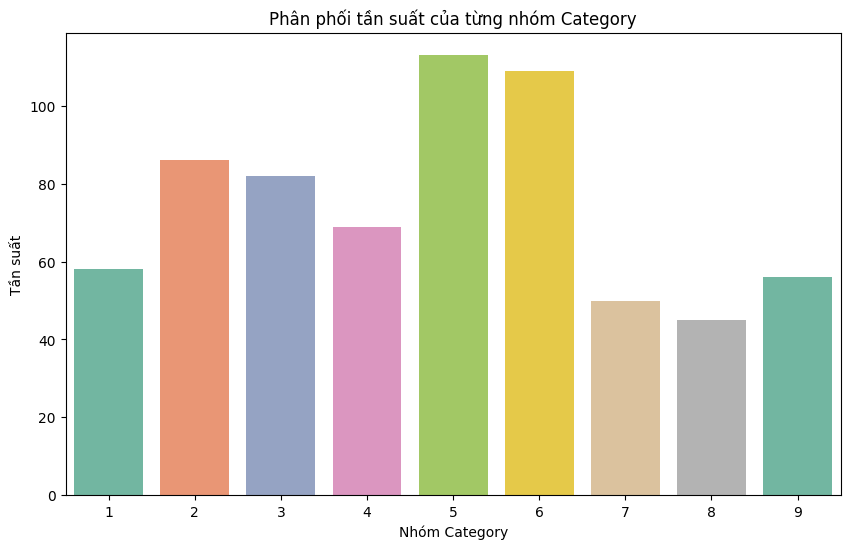

In [37]:
df_exploded = train_data.explode("CategoryGroups").reset_index(drop=True)
df_exploded = df_exploded[df_exploded["CategoryGroups"].notna()]

plt.figure(figsize=(10,6))
sns.countplot(data=df_exploded, x="CategoryGroups", palette="Set2")

plt.title("Phân phối tần suất của từng nhóm Category")
plt.xlabel("Nhóm Category")
plt.ylabel("Tần suất")
plt.show()

**Nhận xét:**
- Nhóm 5 và 6 có tần suất nhiều nhất.
- Nhóm 7 và 8 có tần suất thấp nhất.

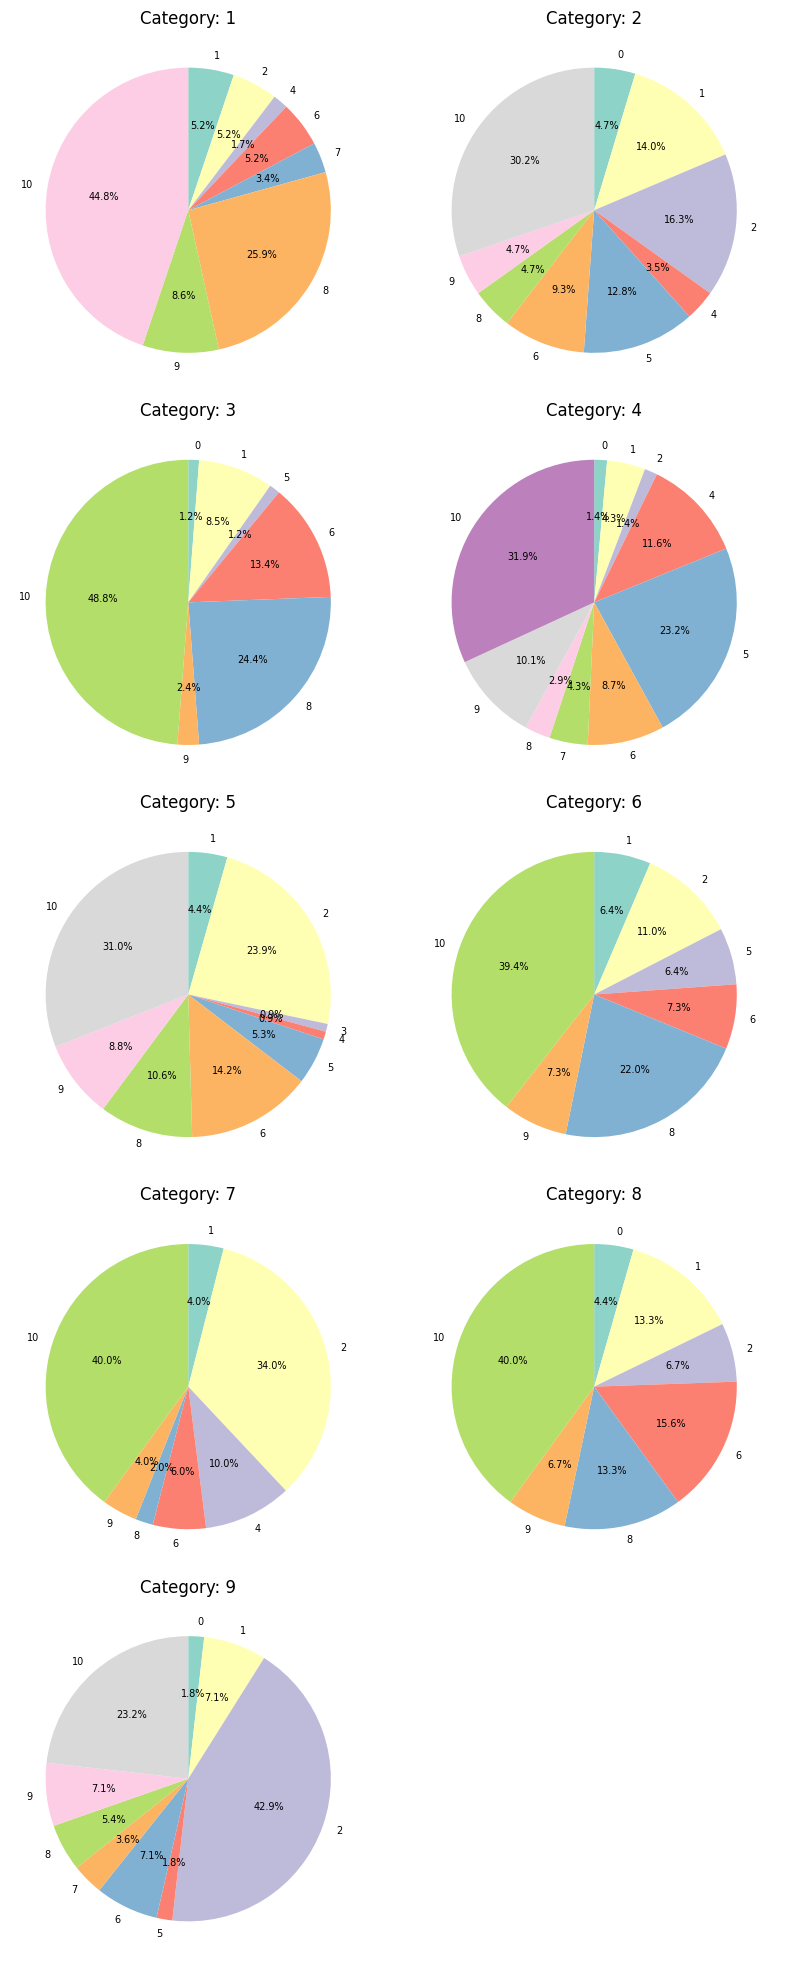

In [38]:
# Nhóm theo CategoryGroups rồi đến Class
dist_by_category = (
    df_exploded.groupby(["CategoryGroups", "Class"])
    .size()
    .reset_index(name="Count")
)

categories = sorted(df_exploded["CategoryGroups"].unique())

fig, axes = plt.subplots(5, 2, figsize=(10, 25))
axes = axes.flatten()

for i, cat in enumerate(categories):
    df_plot = dist_by_category[dist_by_category["CategoryGroups"] == cat]

    axes[i].pie(
        df_plot["Count"],
        labels=df_plot["Class"],
        autopct="%1.1f%%",
        colors=plt.cm.Set3.colors,
        startangle=90,
        textprops={'fontsize': 7},
        counterclock=False
    )
    axes[i].set_title(f"Category: {cat}")
    

for j in range(len(categories), len(axes)):
    axes[j].axis("off")

plt.subplots_adjust(wspace=0.1, hspace=0.1) 
plt.show()

**Nhận xét:**
- Nhóm 1: Class 10, 9, 8 chiếm đa số.
- Nhóm 2: Class 10, 1, 2 chiếm đa số.
- Nhóm 3: Class 10, 8, 6 chiếm đa số.
- Nhóm 4: Class 10, 4, 5 chiếm đa số.
- Nhóm 5: Class 10, 2, 6 chiếm đa số.
- Nhóm 6: Class 10, 8, 2 chiếm đa số.
- Nhóm 7: Class 10, 2, 4 chiếm đa số.
- Nhóm 8: Class 10, 1, 8, 6 chiếm đa số.
- Nhóm 9: Class 2, 10, 1, 6, 9 chiếm đa số.

#### **4) Biến Track Name với biến mục tiêu (Class)**

In [39]:
categories = [
	"edition version".split(" "),
	"remaster remastered".split(" "),
	"acoustic".split(" "),
	"remix".split(" "),
	"feat".split(" ")
]

In [40]:
word_to_category = {}
for i, group in enumerate(categories):
    for w in group:
        word_to_category[w] = i

def get_categories_for_row(text):
    words = clean_text(text).split()
    groups = set()
    for w in words:
        if w in word_to_category:
            groups.add(word_to_category[w] + 1)
    return sorted(groups)

train_data["CategoryGroups2"] = train_data["Track Name"].apply(get_categories_for_row)

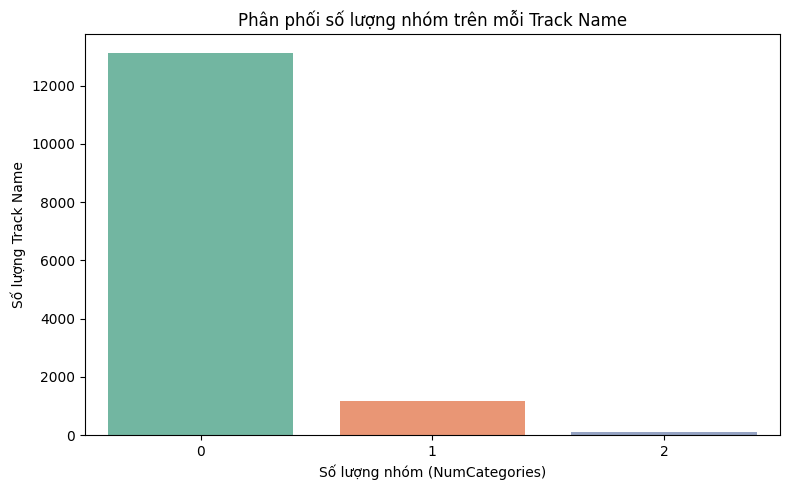

In [41]:
# tạo số lượng nhóm
train_data["NumCategories2"] = train_data["CategoryGroups2"].apply(len)

plt.figure(figsize=(8,5))
sns.countplot(data=train_data, x="NumCategories2", palette="Set2")
plt.title("Phân phối số lượng nhóm trên mỗi Track Name")
plt.xlabel("Số lượng nhóm (NumCategories)")
plt.ylabel("Số lượng Track Name")

plt.tight_layout()
plt.show()

**Nhận xét:**
- Hầu hết các giá trị trong cột Track Name không được mã hóa sang các nhóm phân loại. 

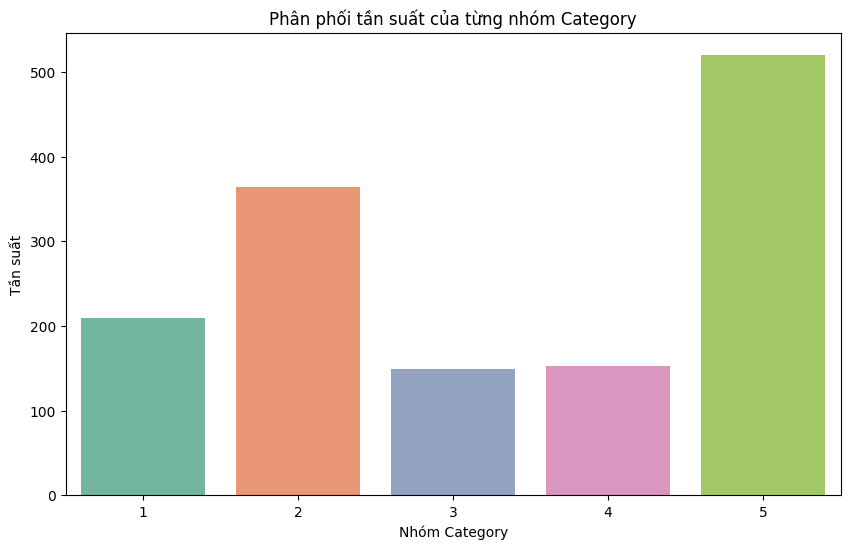

In [42]:
df_exploded = train_data.explode("CategoryGroups2").reset_index(drop=True)
df_exploded = df_exploded[df_exploded["CategoryGroups2"].notna()]

plt.figure(figsize=(10,6))
sns.countplot(data=df_exploded, x="CategoryGroups2", palette="Set2")

plt.title("Phân phối tần suất của từng nhóm Category")
plt.xlabel("Nhóm Category")
plt.ylabel("Tần suất")
plt.show()

**Nhận xét:**
- Nhóm 5 có tần suất xuất hiện nhiều nhất.
- Nhóm 3, 4 có tần suất xuất hiện thấp nhất.

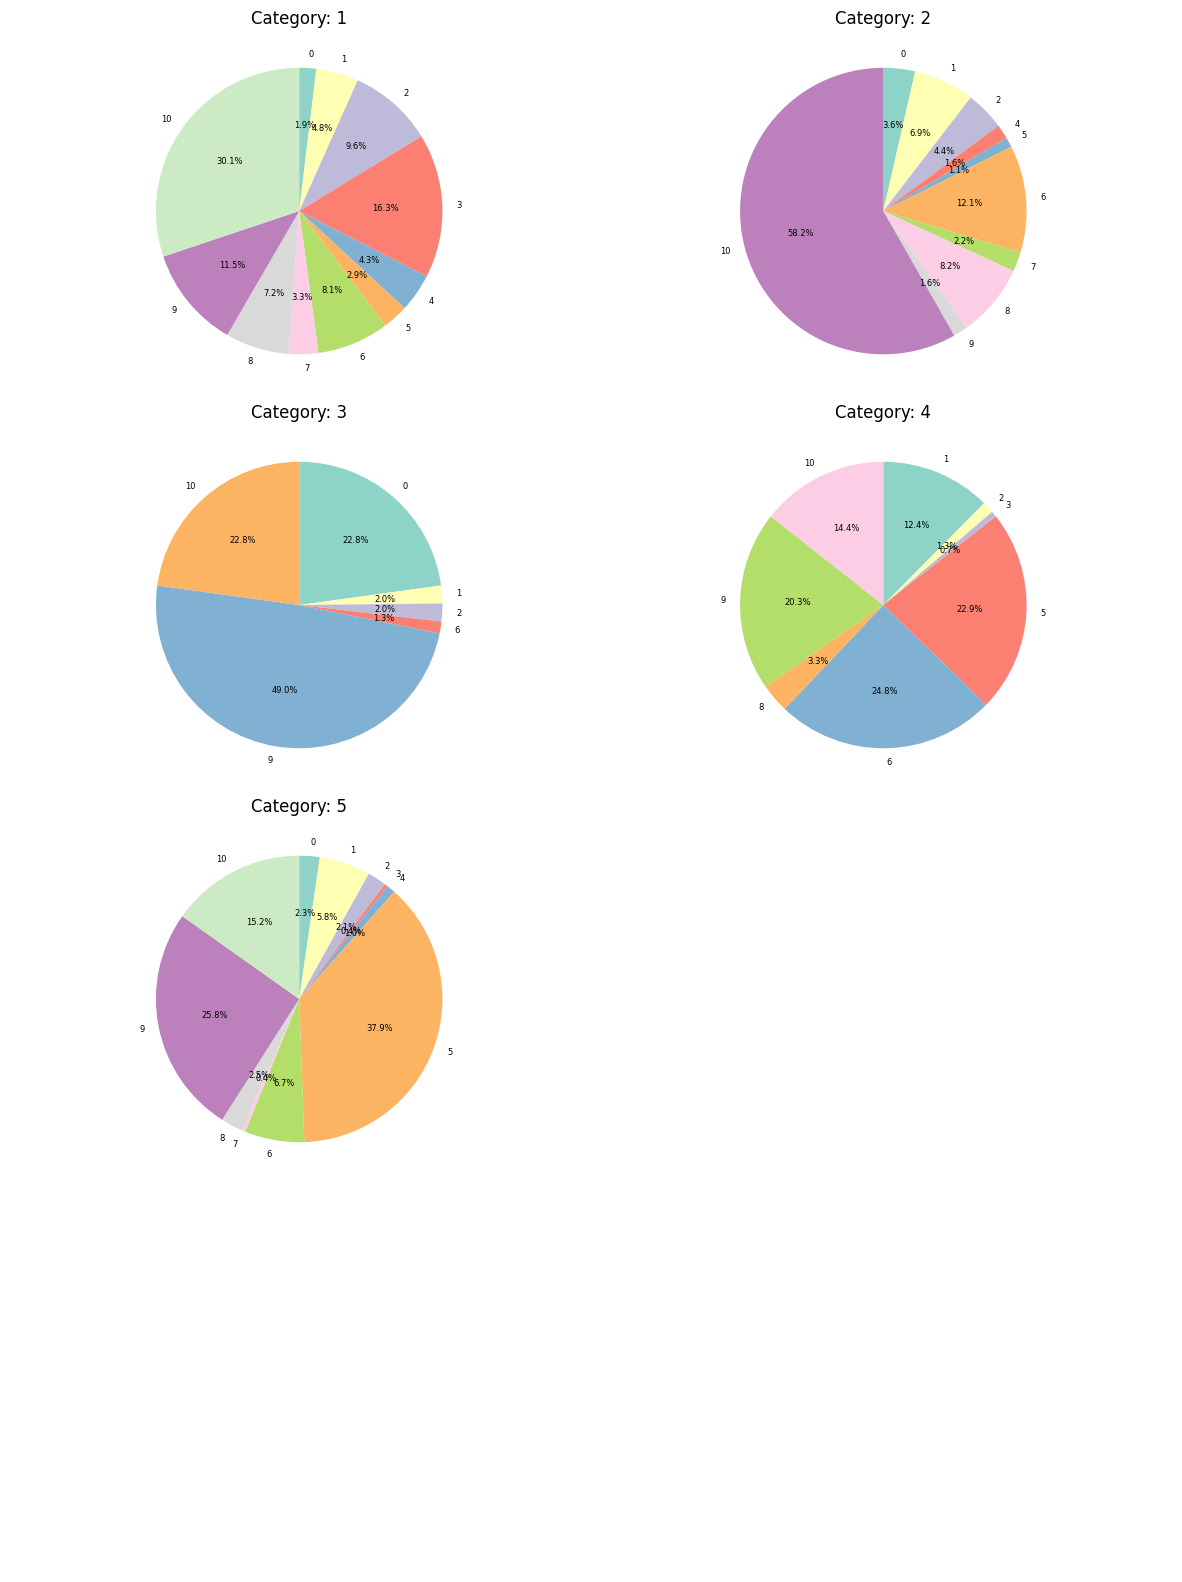

In [43]:
# Nhóm theo CategoryGroups2 rồi đến Class
dist_by_category = (
    df_exploded.groupby(["CategoryGroups2", "Class"])
    .size()
    .reset_index(name="Count")
)

categories = sorted(df_exploded["CategoryGroups2"].unique())

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, cat in enumerate(categories):
    df_plot = dist_by_category[dist_by_category["CategoryGroups2"] == cat]

    axes[i].pie(
        df_plot["Count"],
        labels=df_plot["Class"],
        autopct="%1.1f%%",
        colors=plt.cm.Set3.colors,
        startangle=90,
        textprops={'fontsize': 6},
        counterclock=False
    )
    axes[i].set_title(f"Category: {cat}")
    

for j in range(len(categories), len(axes)):
    axes[j].axis("off")

plt.subplots_adjust(wspace=0.01, hspace=0.1) 
plt.show()

**Nhận xét:**
- Nhóm 1: Class 10, 9, 3 chiếm đa số.
- Nhóm 2: Class 10 chiếm đa số.
- Nhóm 3: Class 9 chiếm đa số.
- Nhóm 4: Class 6, 5, 9 chiếm đa số.
- Nhóm 5: Class 5, 9 chiếm đa số.

### 3.3. Phân tích đa biến

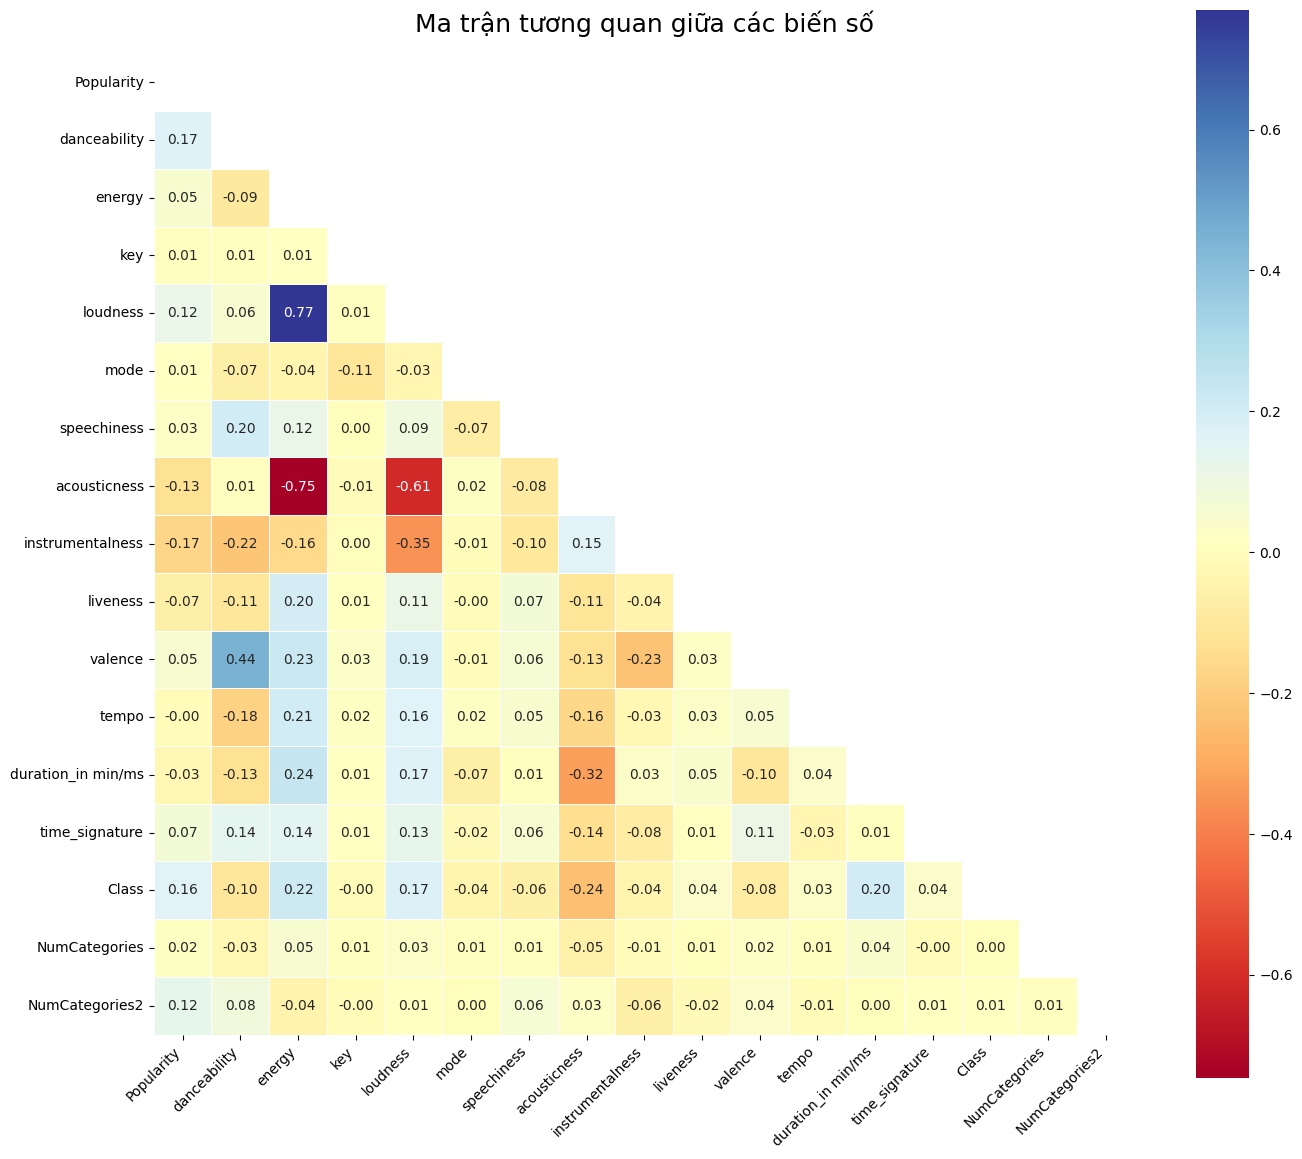

In [44]:
# Lọc đúng các biến dạng số
corr = train_data.select_dtypes(include=['number']).corr()

# Tạo mask để ẩn tam giác trên
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="RdYlBu",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=mask,
    square=True,
)

plt.title("Ma trận tương quan giữa các biến số", fontsize=18, pad=16)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


**Nhận xét:**
- Các nhóm cột có tương quan cao nhất: 
	+ (loudness, energy): 0.77 - năng lượng càng cao thì bản nhạc càng ồn.
	+ (valence, danceability): 0.44 - trạng thái cảm xúc tích cực càng cao thì bản nhạc càng phù hợp cho việc nhảy.

- Các nhóm cột có tương quan thấp nhất:
	+ (acousticness, energy): -0.75 - tính chất mộc càng cao thì năng lượng càng thấp.
	+ (acousticness, loudness): -0.61 - tính chất mộc càng cao thì bản nhạc càng ít ồn.

# **Kết thúc**